# Propuesta 2: Red de Recarga para Vehiculos Electricos en Autopistas

Notebook reproducible para planificar electrolineras en la A-2 usando grafos, optimizacion entera mixta con PuLP y una heuristica voraz de cobertura.

## 1. Introduccion

El problema consiste en elegir ubicaciones candidatas para abrir estaciones de recarga en un corredor de larga distancia, respetando una distancia maxima entre cargadores, una potencia minima disponible y un numero razonable de puntos de carga por estacion.

Se comparan dos enfoques:

- modelo exacto MILP con `PuLP`;
- heuristica voraz de cobertura.

## 2. Carga de librerias

Si `pulp` no esta instalado, usar la celda siguiente de instalacion y volver a ejecutar el notebook desde el principio.

In [1]:
from pathlib import Path
import time
import math
import json
import re
import unicodedata
import heapq
import warnings

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ImportError:
    plt = None
    HAS_MATPLOTLIB = False
    print('Matplotlib no esta instalado. Se usara Pillow para guardar PNG basicos.')

try:
    import networkx as nx
    HAS_NETWORKX = True
except ImportError:
    nx = None
    HAS_NETWORKX = False
    print('NetworkX no esta instalado. El grafo se representara mediante tabla de aristas.')

try:
    import pulp
    PULP_AVAILABLE = True
except ImportError:
    pulp = None
    PULP_AVAILABLE = False
    print('PuLP no esta instalado. Ejecuta una celda con: pip install pulp')

try:
    from PIL import Image, ImageDraw, ImageFont
    HAS_PIL = True
except ImportError:
    Image = ImageDraw = ImageFont = None
    HAS_PIL = False

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 140)

## 3. Carga de datos

Se localizan los CSV filtrados si existen.

In [2]:
def get_repo_root():
    cwd = Path.cwd()
    if cwd.name.lower() == 'src':
        return Path('..')
    return Path('.')


def first_existing(relative_paths, description):
    for rel_path in relative_paths:
        path = REPO_ROOT / rel_path
        if path.exists():
            return path
    tried = '\n'.join(str(REPO_ROOT / p) for p in relative_paths)
    raise FileNotFoundError(f'No se encontro {description}. Rutas probadas:\n{tried}')


def first_existing_or_glob(relative_paths, glob_patterns, description):
    for rel_path in relative_paths:
        path = REPO_ROOT / rel_path
        if path.exists():
            return path

    matches = []
    for pattern in glob_patterns:
        matches.extend(sorted(REPO_ROOT.glob(str(pattern))))

    unique_matches = []
    seen = set()
    for path in matches:
        if path not in seen and path.exists():
            unique_matches.append(path)
            seen.add(path)

    if unique_matches:
        return unique_matches[0]

    tried = '\n'.join(
        [str(REPO_ROOT / p) for p in relative_paths]
        + [str(REPO_ROOT / p) for p in glob_patterns]
    )
    raise FileNotFoundError(f'No se encontro {description}. Rutas probadas:\n{tried}')


REPO_ROOT = get_repo_root()
OUTPUT_DIR = REPO_ROOT / 'output'

tramos_path = first_existing(
    [Path('data/filtrado/tramos_a2.csv'), Path('data/datos filtrados/tramos_a2.csv')],
    'tramos_a2.csv',
)
estaciones_path = first_existing(
    [Path('data/filtrado/estaciones_a2.csv'), Path('data/datos filtrados/estaciones_a2.csv')],
    'estaciones_a2.csv',
)

subestaciones_path = first_existing_or_glob(
    [
        Path('data/filtrado/cnmc_demanda_distribucion_a2_15km_resumen_subestacion.csv'),
        Path('data/filtrado/cnmc_demanda_distribucion_a2_15km.csv'),
        Path('data/datos filtrados/cnmc_demanda_distribucion_a2_15km_resumen_subestacion.csv'),
        Path('data/datos filtrados/cnmc_demanda_distribucion_a2_15km.csv'),
        Path('data/filtrado/subestaciones_a2.csv'),
        Path('data/datos filtrados/subestaciones_a2.csv'),
        Path('subestaciones_a2.csv'),
    ],
    [
        Path('data/filtrado/*demanda*distribucion*a2*15km*resumen*.csv'),
        Path('data/filtrado/*demanda*distribucion*a2*15km*.csv'),
        Path('data/filtrado/*Demanda*Distribucion*a2*15km*.csv'),
        Path('data/filtrado/*Demanda*Distribución*a2*15km*.csv'),
        Path('data/datos filtrados/*demanda*distribucion*a2*15km*resumen*.csv'),
        Path('data/datos filtrados/*demanda*distribucion*a2*15km*.csv'),
        Path('data/raw/*Demanda*Distribucion*.csv'),
        Path('data/raw/*Demanda*Distribución*.csv'),
    ],
    'CSV de capacidad real de demanda en distribucion',
)

tramos_raw = pd.read_csv(tramos_path)
estaciones_raw = pd.read_csv(estaciones_path)
subestaciones_raw = pd.read_csv(subestaciones_path)

print('Tramos:', tramos_path)
print('Estaciones:', estaciones_path)
print('Capacidad electrica usada:', subestaciones_path)
display(pd.DataFrame({
    'tabla': ['tramos', 'estaciones', 'capacidad_demanda_distribucion'],
    'filas': [len(tramos_raw), len(estaciones_raw), len(subestaciones_raw)],
    'columnas': [tramos_raw.shape[1], estaciones_raw.shape[1], subestaciones_raw.shape[1]],
}))


Tramos: ..\data\filtrado\tramos_a2.csv
Estaciones: ..\data\filtrado\estaciones_a2.csv
Capacidad electrica usada: ..\data\filtrado\subestaciones_a2.csv


,tabla,filas,columnas
0,tramos,138,12
1,estaciones,97,11
2,capacidad_demanda_distribucion,370,9


In [ ]:
print("=== ANÁLISIS DEL GRAFO DE CANDIDATOS ===\n")
if HAS_NETWORKX:
    # 1. Componentes conexas
    componentes = list(nx.connected_components(G))
    print(f"Componentes conexas: {len(componentes)}")
    for i, comp in enumerate(componentes):
        print(f"  Componente {i+1}: {len(comp)} nodos")
    
    # 2. Árbol recubridor mínimo (MST)
    if G.number_of_edges() > 0:
        mst = nx.minimum_spanning_tree(G, weight='distancia_km')
        peso_total = sum(nx.get_edge_attributes(mst, 'distancia_km').values())
        print(f"\nÁrbol recubridor mínimo (MST):")
        print(f"  Número de aristas: {mst.number_of_edges()}")
        print(f"  Peso total: {peso_total:.2f} km")
        
        # 3. Diámetro (si el grafo es conexo)
        if nx.is_connected(G):
            diam = nx.diameter(G, weight='distancia_km')
            print(f"\nDiámetro del grafo (máxima distancia entre candidatos): {diam:.2f} km")
            
            # 4. Camino más largo (opcional)
            # Nota: en un grafo no dirigido con pesos, el diámetro ya es el camino más largo
        else:
            print("\nEl grafo no es conexo: no se puede calcular el diámetro")
            
    # 5. Nodos con mayor centralidad (para identificar candidatos críticos)
    if G.number_of_nodes() > 0:
        centrality = nx.betweenness_centrality(G, weight='distancia_km')
        top_central = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:5]
        print(f"\nTop 5 candidatos con mayor centralidad (más conexos):")
        for node, val in top_central:
            pk = G.nodes[node].get('pk', 'N/A')
            print(f"  {node} (PK={pk}): centralidad = {val:.4f}")
else:
    print("NetworkX no disponible, no se puede analizar el grafo.")

## 4. Limpieza de datos

Se normalizan nombres, tipos numericos, kilometraje, demanda estimada y contexto electrico de subestaciones cercanas.

In [3]:
autonomia_referencia_km = 350.0
bat_salida = 0.80
bat_llegada_min = 0.10
distancia_max_km = round(autonomia_referencia_km * (bat_salida - bat_llegada_min), 3)

PARAMS = {
    'autonomia_referencia_km': autonomia_referencia_km,
    'bat_salida': bat_salida,
    'bat_llegada_min': bat_llegada_min,
    'distancia_max_km': distancia_max_km,
    'radio_cobertura_km': distancia_max_km / 2,
    'radio_subestacion_km': 15.0,
    'potencia_minima_mw': 0.50,
    'separacion_minima_km': 30.0,
    'filtrar_candidatos_sin_potencia': False,
    'crear_candidatos_refuerzo_si_no_factible': True,
    'penalizacion_candidato_refuerzo': 700.0,
    'cuota_ve': 0.03,
    'proporcion_recarga_corredor': 0.08,
    'factor_longitud_demanda': 100.0,
    'puntos_min': 2,
    'puntos_max': 6,
    'utilizacion_objetivo': 0.70,
}

POWER = pd.DataFrame([
    {'tipo': '50kW', 'kw': 50, 'servicio_min': 60, 'coste_punto': 35, 'mw': 0.050},
    {'tipo': '150kW', 'kw': 150, 'servicio_min': 35, 'coste_punto': 80, 'mw': 0.150},
    {'tipo': '350kW', 'kw': 350, 'servicio_min': 25, 'coste_punto': 150, 'mw': 0.350},
])
POWER['capacidad_dia_por_punto'] = 24 * 60 * PARAMS['utilizacion_objetivo'] / POWER['servicio_min']
print(f"D_max calculado desde autonomia: {PARAMS['distancia_max_km']:.1f} km")
print(f"Radio de cobertura: {PARAMS['radio_cobertura_km']:.1f} km")


def normalize_columns(df):
    out = df.copy()
    cols = []
    for col in out.columns:
        name = str(col).strip()
        name = unicodedata.normalize('NFKD', name)
        name = ''.join(ch for ch in name if not unicodedata.combining(ch))
        name = name.lower()
        name = re.sub(r'[^a-z0-9]+', '_', name)
        name = re.sub(r'_+', '_', name).strip('_')
        cols.append(name)
    out.columns = cols
    return out


def to_number(df, columns):
    for col in columns:
        if col in df.columns:
            df[col] = pd.to_numeric(
                df[col].astype(str).str.replace(',', '.', regex=False).str.strip(),
                errors='coerce',
            )
    return df


tramos = normalize_columns(tramos_raw)
estaciones = normalize_columns(estaciones_raw)
subestaciones = normalize_columns(subestaciones_raw)

tramos = tramos.rename(columns={'id_provinc': 'id_provincia'})
estaciones = estaciones.rename(columns={'id_provinc': 'id_provincia', 'porc_pesad': 'porc_pesado'})
subestaciones = subestaciones.rename(columns={
    'identificador_punto': 'identificador_punto_conexion',
    'coordenada_x': 'utm_x',
    'coordenada_y': 'utm_y',
    'capacidad_disponible': 'capacidad_disponible_mw',
    'nivel_de_tension': 'nivel_tension_kv',
})
if 'utm_x' not in subestaciones.columns and 'x' in subestaciones.columns:
    subestaciones = subestaciones.rename(columns={'x': 'utm_x'})
if 'utm_y' not in subestaciones.columns and 'y' in subestaciones.columns:
    subestaciones = subestaciones.rename(columns={'y': 'utm_y'})

tramos = to_number(tramos, ['pk_inicio', 'pk_fin', 'longitud', 'imd_total', 'imd_pesado', 'imd_ligero', 'utm_x', 'utm_y'])
estaciones = to_number(estaciones, ['pk', 'imd_total', 'imd_pesado', 'imd_ligero', 'utm_x', 'utm_y'])
subestaciones = to_number(subestaciones, [
    'utm_x', 'utm_y', 'nivel_tension_kv', 'capacidad_disponible_mw',
    'capacidad_ocupada_mw', 'capacidad_admitida_y_no_evaluada_mw',
])

tramos = tramos.dropna(subset=['pk_inicio', 'pk_fin']).copy()
tramos = tramos[tramos['pk_fin'] > tramos['pk_inicio']].copy()
tramos['longitud'] = tramos['longitud'].fillna(tramos['pk_fin'] - tramos['pk_inicio'])
tramos['pk_centro'] = (tramos['pk_inicio'] + tramos['pk_fin']) / 2
tramos['imd_total'] = tramos['imd_total'].fillna(tramos['imd_total'].median())
tramos['demanda_cargas_dia'] = (
    tramos['imd_total'] * PARAMS['cuota_ve'] * PARAMS['proporcion_recarga_corredor']
    * tramos['longitud'].clip(lower=0) / PARAMS['factor_longitud_demanda']
)
tramos = tramos.sort_values(['pk_inicio', 'pk_fin']).reset_index(drop=True)
tramos['tramo_id'] = ['T%03d' % i for i in range(len(tramos))]

estaciones = estaciones.dropna(subset=['pk']).copy().sort_values('pk').reset_index(drop=True)
if 'capacidad_disponible_mw' not in subestaciones.columns:
    raise ValueError('El CSV de capacidad electrica no tiene columna de capacidad disponible MW.')

subestaciones['capacidad_disponible_mw'] = subestaciones['capacidad_disponible_mw'].fillna(0).clip(lower=0)
subestaciones = subestaciones.dropna(subset=['utm_x', 'utm_y']).reset_index(drop=True)

print('PK inicial:', round(tramos['pk_inicio'].min(), 2))
print('PK final:', round(tramos['pk_fin'].max(), 2))
print('Demanda estimada total:', round(tramos['demanda_cargas_dia'].sum(), 1), 'cargas/dia')
print('Subestaciones/nudos de demanda cargados:', len(subestaciones))
print('Capacidad total publicada cerca de A-2:', round(subestaciones['capacidad_disponible_mw'].sum(), 2), 'MW')
print('Capacidad maxima publicada en un nudo:', round(subestaciones['capacidad_disponible_mw'].max(), 2), 'MW')
display(tramos.head())
display(subestaciones.head())


D_max calculado desde autonomia: 245.0 km
Radio de cobertura: 122.5 km
PK inicial: 5.9
PK final: 734.0
Demanda estimada total: 519.8 cargas/dia
Subestaciones/nudos de demanda cargados: 370
Capacidad total publicada cerca de A-2: 8714.93 MW
Capacidad maxima publicada en un nudo: 332.96 MW


,id_tramo,carretera,pk_inicio,pk_fin,longitud,id_provincia,provincia,imd_total,imd_pesado,imd_ligero,utm_x,utm_y,pk_centro,demanda_cargas_dia,tramo_id
0,554540411A5F46392749F96964008999,A-2,5.900,10.100,4.200,28,Madrid,125529.0,5888.0,119641,447464.421559,4.477832e+06,8.000,12.653323,T000
1,5545404112F5C4932749F96964008A11,A-2,10.100,14.800,4.700,28,Madrid,133039.0,7122.0,125917,451874.676325,4.477788e+06,12.450,15.006799,T001
2,5545404112D766B32749F96964008BC7,A-2,14.800,16.800,2.030,28,Madrid,139855.0,9963.0,129892,455152.822678,4.477626e+06,15.800,6.813736,T002
3,5545404112D5CC932749F96964008C73,A-2,16.800,17.732,1.054,28,Madrid,120800.0,6765.0,114035,456533.523743,4.478133e+06,17.266,3.055757,T003
4,5545404112D5CC932749F96964008C73,A-2,17.732,20.100,2.676,28,Madrid,183173.0,20702.0,162471,457981.973168,4.479015e+06,18.916,11.764103,T004


,provincia,municipio,utm_x,utm_y,subestacion,nivel_tension_kv,capacidad_disponible_mw,denominacion_punto,identificador_punto_conexion
0,Guadalajara,Alovera,479370.575522,4.492555e+06,3619,132,0.0,ALOVERA 132.00,25004016
1,Guadalajara,Alovera,479370.575522,4.492555e+06,3619,45,0.0,ALOVERA 45.000,25030721
2,Guadalajara,Alovera,479370.575522,4.492555e+06,3619,20,0.0,ALOVERA T1,319065018
3,Guadalajara,Alovera,479370.575522,4.492555e+06,3619,20,0.0,ALOVERA T2,319065020
4,Guadalajara,Cabanillas del Campo,478751.597899,4.496172e+06,3267,132,0.0,CABANILL 132.00,25009048


In [4]:
def validar_tramos(tramos):
    datos = tramos.sort_values(['pk_inicio', 'pk_fin']).reset_index(drop=True).copy()
    datos['longitud_pk_km'] = datos['pk_fin'] - datos['pk_inicio']
    datos['diferencia_longitud_vs_pk_km'] = datos['longitud'] - datos['longitud_pk_km']
    datos['pk_fin_anterior'] = datos['pk_fin'].shift()
    datos['tramo_anterior'] = datos['tramo_id'].shift()
    datos['hueco_desde_anterior_km'] = datos['pk_inicio'] - datos['pk_fin_anterior']

    tolerancia = 1e-6
    huecos = datos[datos['hueco_desde_anterior_km'] > tolerancia].copy()
    solapes = datos[datos['hueco_desde_anterior_km'] < -tolerancia].copy()
    diferencias = datos[datos['diferencia_longitud_vs_pk_km'].abs() > 0.01].copy()

    resumen = pd.DataFrame([{
        'pk_inicial': float(datos['pk_inicio'].min()),
        'pk_final': float(datos['pk_fin'].max()),
        'longitud_total_tramos_km': float(datos['longitud'].sum()),
        'pk_final_menos_pk_inicial_km': float(datos['pk_fin'].max() - datos['pk_inicio'].min()),
        'numero_tramos': int(len(datos)),
        'numero_huecos': int(len(huecos)),
        'km_totales_huecos': float(huecos['hueco_desde_anterior_km'].sum()) if len(huecos) else 0.0,
        'numero_solapes': int(len(solapes)),
        'km_totales_solapes': float((-solapes['hueco_desde_anterior_km']).sum()) if len(solapes) else 0.0,
        'max_diferencia_longitud_vs_pk_km': float(datos['diferencia_longitud_vs_pk_km'].abs().max()),
    }])

    cols_eventos = ['tramo_anterior', 'tramo_id', 'pk_fin_anterior', 'pk_inicio', 'pk_fin', 'hueco_desde_anterior_km']
    cols_diferencias = ['tramo_id', 'pk_inicio', 'pk_fin', 'longitud', 'longitud_pk_km', 'diferencia_longitud_vs_pk_km']
    return resumen, huecos[cols_eventos], solapes[cols_eventos], diferencias[cols_diferencias]


resumen_validacion_tramos, huecos_tramos, solapes_tramos, diferencias_longitud_tramos = validar_tramos(tramos)
print('Validacion de tramos de la A-2')
display(resumen_validacion_tramos)
print('Huecos entre tramos detectados')
display(huecos_tramos)
print('Solapes entre tramos detectados')
display(solapes_tramos)
print('Diferencias entre longitud declarada y pk_fin - pk_inicio')
display(diferencias_longitud_tramos.head(20))


Validacion de tramos de la A-2


,pk_inicial,pk_final,longitud_total_tramos_km,pk_final_menos_pk_inicial_km,numero_tramos,numero_huecos,km_totales_huecos,numero_solapes,km_totales_solapes,max_diferencia_longitud_vs_pk_km
0,5.9,734.0,536.075,728.1,138,3,192.498,0,0.0,0.71


Huecos entre tramos detectados


,tramo_anterior,tramo_id,pk_fin_anterior,pk_inicio,pk_fin,hueco_desde_anterior_km
74,T073,T074,340.00,431.010,432.7,91.010
129,T128,T129,610.69,692.208,694.4,81.518
136,T135,T136,709.23,729.200,731.9,19.970


Solapes entre tramos detectados


,tramo_anterior,tramo_id,pk_fin_anterior,pk_inicio,pk_fin,hueco_desde_anterior_km


Diferencias entre longitud declarada y pk_fin - pk_inicio


,tramo_id,pk_inicio,pk_fin,longitud,longitud_pk_km,diferencia_longitud_vs_pk_km
2,T002,14.800,16.800,2.030,2.000,0.030
3,T003,16.800,17.732,1.054,0.932,0.122
4,T004,17.732,20.100,2.676,2.368,0.308
7,T007,23.400,27.800,4.590,4.400,0.190
8,T008,27.800,31.300,3.400,3.500,-0.100
9,T009,31.300,38.100,6.950,6.800,0.150
10,T010,38.100,38.760,0.675,0.660,0.015
11,T011,38.760,41.600,2.811,2.840,-0.029
12,T012,41.600,44.000,2.375,2.400,-0.025
13,T013,44.000,47.300,3.266,3.300,-0.034


In [5]:
def add_substation_features(candidates, substations):
    candidates = candidates.copy()
    if substations.empty or candidates[['utm_x', 'utm_y']].isna().any(axis=None):
        candidates['dist_subestacion_km'] = 999.0
        candidates['capacidad_entorno_mw'] = 0.0
        candidates['nudos_demanda_15km'] = 0
        candidates['subestacion_cercana'] = None
        return candidates

    cand_xy = candidates[['utm_x', 'utm_y']].to_numpy(float)
    sub_xy = substations[['utm_x', 'utm_y']].to_numpy(float)
    dist = np.sqrt(((cand_xy[:, None, :] - sub_xy[None, :, :]) ** 2).sum(axis=2)) / 1000.0
    cap = substations['capacidad_disponible_mw'].fillna(0).to_numpy(float)

    nearest = dist.argmin(axis=1)
    candidates['dist_subestacion_km'] = dist[np.arange(len(candidates)), nearest]

    within = dist <= PARAMS['radio_subestacion_km']
    candidates['nudos_demanda_15km'] = within.sum(axis=1).astype(int)

    cap_near = np.where(within, cap[None, :], np.nan)
    max_cap = np.zeros(len(candidates), dtype=float)
    best_cap_idx = np.full(len(candidates), -1, dtype=int)
    for row_idx in range(len(candidates)):
        if np.isfinite(cap_near[row_idx]).any():
            best_local = int(np.nanargmax(cap_near[row_idx]))
            max_cap[row_idx] = float(cap[best_local])
            best_cap_idx[row_idx] = best_local
        else:
            max_cap[row_idx] = 0.0

    candidates['capacidad_entorno_mw'] = max_cap

    ref_idx = np.where(best_cap_idx >= 0, best_cap_idx, nearest)
    for src_col, dst_col in [
        ('subestacion', 'subestacion_cercana'),
        ('municipio', 'municipio_subestacion'),
        ('provincia', 'provincia_subestacion'),
        ('nombre_del_gestor', 'gestor_subestacion'),
        ('gestor_de_red', 'codigo_gestor_red'),
        ('nivel_tension_kv', 'nivel_tension_kv_entorno'),
    ]:
        if src_col in substations.columns:
            candidates[dst_col] = [substations.iloc[i][src_col] for i in ref_idx]
    return candidates


def build_candidates(tramos, estaciones, subestaciones):
    cand_est = estaciones.rename(columns={'pk': 'pk_candidato'}).copy()
    cand_est['tipo_candidato'] = 'estacion_aforo'
    cand_est['es_estacion_aforo'] = 1
    cand_est = cand_est[['pk_candidato', 'utm_x', 'utm_y', 'tipo_candidato', 'es_estacion_aforo']]

    cand_tramos = tramos.rename(columns={'pk_centro': 'pk_candidato'}).copy()
    cand_tramos['tipo_candidato'] = 'centroide_tramo'
    cand_tramos['es_estacion_aforo'] = 0
    cand_tramos = cand_tramos[['pk_candidato', 'utm_x', 'utm_y', 'tipo_candidato', 'es_estacion_aforo']]

    cand = pd.concat([cand_est, cand_tramos], ignore_index=True).dropna(subset=['pk_candidato'])
    cand['pk_round'] = cand['pk_candidato'].round(3)
    cand = cand.groupby('pk_round', as_index=False).agg(
        pk=('pk_candidato', 'mean'),
        utm_x=('utm_x', 'mean'),
        utm_y=('utm_y', 'mean'),
        tipo_candidato=('tipo_candidato', lambda s: '+'.join(sorted(set(s)))),
        es_estacion_aforo=('es_estacion_aforo', 'max'),
    ).sort_values('pk').reset_index(drop=True)
    cand['candidate_id'] = ['C%03d' % i for i in range(len(cand))]
    cand = add_substation_features(cand, subestaciones)

    dist_pk = np.abs(cand['pk'].to_numpy()[:, None] - tramos['pk_centro'].to_numpy()[None, :])
    weights = np.clip(1 - dist_pk / PARAMS['radio_cobertura_km'], 0, 1)
    cand['demanda_potencial_dia'] = weights @ tramos['demanda_cargas_dia'].to_numpy()
    demanda_norm = cand['demanda_potencial_dia'] / cand['demanda_potencial_dia'].max()
    refuerzo_min = (PARAMS['potencia_minima_mw'] - cand['capacidad_entorno_mw']).clip(lower=0)

    cand['cumple_500_kva'] = cand['capacidad_entorno_mw'] >= PARAMS['potencia_minima_mw']
    cand['candidato_elegible_potencia'] = True
    cand['coste_fijo'] = (
        120
        + 2.0 * cand['dist_subestacion_km'].clip(upper=60)
        + 260 * refuerzo_min
        - 35 * demanda_norm
        - 12 * cand['es_estacion_aforo']
    ).clip(lower=30)
    return cand


candidatos = build_candidates(tramos, estaciones, subestaciones)
display(candidatos.head())
print('Candidatos:', len(candidatos))
print('Candidatos con >= 500 kVA publicados a 15 km:', int(candidatos['cumple_500_kva'].sum()))
print('Candidatos sin nudo CNMC de demanda dentro de 15 km:', int((candidatos['nudos_demanda_15km'] == 0).sum()))


,pk_round,pk,utm_x,utm_y,tipo_candidato,es_estacion_aforo,candidate_id,dist_subestacion_km,nudos_demanda_15km,capacidad_entorno_mw,subestacion_cercana,municipio_subestacion,provincia_subestacion,nivel_tension_kv_entorno,demanda_potencial_dia,cumple_500_kva,candidato_elegible_potencia,coste_fijo
0,8.00,8.00,447464.421559,4.477832e+06,centroide_tramo,0,C000,4.335205,120,332.96,3583,Madrid,Madrid,132,136.773533,True,True,98.101088
1,8.25,8.25,447705.648502,4.477848e+06,estacion_aforo,1,C001,4.561032,120,332.96,3583,Madrid,Madrid,132,137.112908,True,True,86.476891
2,12.45,12.45,451874.676325,4.477788e+06,centroide_tramo,0,C002,5.341917,99,332.96,3583,Madrid,Madrid,132,142.837144,True,True,98.759275
3,12.50,12.50,451942.404641,4.477818e+06,estacion_aforo,1,C003,5.282156,99,332.96,3583,Madrid,Madrid,132,142.893337,True,True,86.627193
4,12.53,12.53,451961.905863,4.477816e+06,estacion_aforo,1,C004,5.262884,99,332.96,3583,Madrid,Madrid,132,142.927053,True,True,86.581114


Candidatos: 219
Candidatos con >= 500 kVA publicados a 15 km: 31
Candidatos sin nudo CNMC de demanda dentro de 15 km: 168


In [6]:
def tramos_reales_a2(tramos, max_hueco_pk=5.0):
    datos = tramos.dropna(subset=['pk_inicio', 'pk_fin', 'utm_x', 'utm_y']).sort_values('pk_inicio')
    segmentos = []
    actual = []
    pk_fin_anterior = None
    for _, row in datos.iterrows():
        if pk_fin_anterior is not None and (row['pk_inicio'] - pk_fin_anterior) > max_hueco_pk:
            if actual:
                segmentos.append(pd.DataFrame(actual))
            actual = []
        actual.append(row.to_dict())
        pk_fin_anterior = row['pk_fin']
    if actual:
        segmentos.append(pd.DataFrame(actual))
    return segmentos


def _segmento_bounds_local(segmento):
    return float(segmento['pk_inicio'].min()), float(segmento['pk_fin'].max())


def _row_nearest_pk(segmento, pk):
    idx = (segmento['pk_centro'] - pk).abs().idxmin()
    return segmento.loc[idx]


def _eligible_pk_values(cand, pk_start, pk_end):
    local = cand[(cand['pk'] >= pk_start) & (cand['pk'] <= pk_end)].copy()
    if PARAMS.get('filtrar_candidatos_sin_potencia', False):
        if 'candidato_elegible_potencia' in local.columns:
            local = local[local['candidato_elegible_potencia'].fillna(False).astype(bool)]
        else:
            local = local[local['capacidad_entorno_mw'].fillna(0) >= PARAMS['potencia_minima_mw']]
    return local['pk'].dropna().to_numpy(float)


def _pk_is_covered_by_eligible(pk, eligible_pks, radio):
    if len(eligible_pks) == 0:
        return False
    return bool(np.min(np.abs(eligible_pks - float(pk))) <= radio + 1e-9)


def _make_refuerzo_candidate(segmento, pk, aux_id):
    nearest = _row_nearest_pk(segmento, pk)
    demanda_ref = float(nearest.get('demanda_cargas_dia', 0.0))
    coste_base = float(PARAMS.get('penalizacion_candidato_refuerzo', 700.0))
    return {
        'pk': float(pk),
        'utm_x': float(nearest.get('utm_x', np.nan)),
        'utm_y': float(nearest.get('utm_y', np.nan)),
        'tipo_candidato': 'refuerzo_red_auxiliar',
        'es_estacion_aforo': 0,
        'dist_subestacion_km': np.nan,
        'capacidad_entorno_mw': float(PARAMS['potencia_minima_mw']),
        'demanda_potencial_dia': demanda_ref,
        'cumple_500_kva': True,
        'candidato_elegible_potencia': True,
        'coste_fijo': coste_base,
        'es_auxiliar': 1,
        'aux_id': aux_id,
    }


def add_reinforcement_candidates_for_feasibility(cand):
    cand = cand.copy().sort_values('pk').reset_index(drop=True)

    if not (
        PARAMS.get('crear_candidatos_refuerzo_si_no_factible', True)
        and PARAMS.get('filtrar_candidatos_sin_potencia', False)
    ):
        return cand

    if 'es_auxiliar' not in cand.columns:
        cand['es_auxiliar'] = 0
    if 'candidato_elegible_potencia' not in cand.columns:
        cand['candidato_elegible_potencia'] = cand['capacidad_entorno_mw'].fillna(0) >= PARAMS['potencia_minima_mw']

    radio = float(PARAMS['radio_cobertura_km'])
    nuevos = []
    aux_id = 0

    for segmento in segmentos_a2:
        pk_start, pk_end = _segmento_bounds_local(segmento)

        grid = list(np.arange(pk_start, pk_end + 0.001, 1.0))
        puntos = pd.Series(
            [pk_start, pk_end]
            + segmento['pk_centro'].dropna().astype(float).tolist()
            + grid
        ).round(3).drop_duplicates().sort_values().tolist()

        eligible_pks = _eligible_pk_values(cand, pk_start, pk_end)

        for pk in puntos:
            if not (pk_start <= pk <= pk_end):
                continue

            if _pk_is_covered_by_eligible(pk, eligible_pks, radio):
                continue

            nuevo = _make_refuerzo_candidate(segmento, pk, aux_id)
            nuevos.append(nuevo)
            aux_id += 1

            eligible_pks = np.append(eligible_pks, float(pk))

    if nuevos:
        cand = pd.concat([cand, pd.DataFrame(nuevos)], ignore_index=True, sort=False)

    return cand


def repair_candidate_gaps(candidatos):
    cand = candidatos.copy().sort_values('pk').reset_index(drop=True)

    if 'es_auxiliar' not in cand.columns:
        cand['es_auxiliar'] = 0
    if 'es_estacion_aforo' not in cand.columns:
        cand['es_estacion_aforo'] = 0

    cand['capacidad_entorno_mw'] = cand['capacidad_entorno_mw'].fillna(0).clip(lower=0)
    cand['cumple_500_kva'] = cand['capacidad_entorno_mw'] >= PARAMS['potencia_minima_mw']
    if PARAMS.get('filtrar_candidatos_sin_potencia', False):
        cand['candidato_elegible_potencia'] = cand['cumple_500_kva'] | cand['es_auxiliar'].fillna(0).eq(1)
    else:
        cand['candidato_elegible_potencia'] = True

    cand = add_reinforcement_candidates_for_feasibility(cand)

    cand['capacidad_entorno_mw'] = cand['capacidad_entorno_mw'].fillna(0).clip(lower=0)
    cand['cumple_500_kva'] = cand['capacidad_entorno_mw'] >= PARAMS['potencia_minima_mw']
    if PARAMS.get('filtrar_candidatos_sin_potencia', False):
        cand['candidato_elegible_potencia'] = cand['cumple_500_kva'] | cand['es_auxiliar'].fillna(0).eq(1)
    else:
        cand['candidato_elegible_potencia'] = True
    cand['coste_fijo'] = cand['coste_fijo'].fillna(float(PARAMS.get('penalizacion_candidato_refuerzo', 700.0))).clip(lower=30)
    cand['candidate_id'] = ['C%03d' % i for i in range(len(cand))]

    return cand.sort_values('pk').reset_index(drop=True)


segmentos_a2 = tramos_reales_a2(tramos, max_hueco_pk=5.0)
candidatos = repair_candidate_gaps(candidatos)

print('Secciones reales A-2 detectadas:', len(segmentos_a2))
print('Longitud en tramos por seccion:', [len(seg) for seg in segmentos_a2])
print('Candidatos totales tras validacion:', len(candidatos))
print('Candidatos auxiliares de refuerzo:', int(candidatos.get('es_auxiliar', pd.Series(0, index=candidatos.index)).sum()))
print('Candidatos con >= 500 kVA publicados:', int(candidatos['cumple_500_kva'].sum()))
pk_elegibles = np.sort(candidatos.loc[candidatos['candidato_elegible_potencia'], 'pk'].to_numpy(float))
mayor_hueco_elegibles = float(np.diff(pk_elegibles).max()) if len(pk_elegibles) > 1 else 0.0
print('Mayor hueco entre candidatos elegibles:', round(mayor_hueco_elegibles, 3), 'km')


Secciones reales A-2 detectadas: 4
Longitud en tramos por seccion: [74, 55, 7, 2]
Candidatos totales tras validacion: 219
Candidatos auxiliares de refuerzo: 0
Candidatos con >= 500 kVA publicados: 31
Mayor hueco entre candidatos elegibles: 92.205 km


## 5. Definicion formal del problema

Conjunto de candidatos `I`, tramos de demanda `T` y puntos de control `Q` a lo largo del corredor.

Variables principales:

- `x_i`: 1 si se abre electrolinera en el candidato `i`.
- `a_ti`: 1 si el tramo `t` se asigna a la estacion `i`.
- `p50_i`, `p150_i`, `p350_i`: numero de puntos de 50, 150 y 350 kW en `i`.
- `refuerzo_i`: MW adicionales necesarios cuando la capacidad electrica disponible no alcanza.

Restricciones:

- cada tramo se cubre por una estacion dentro del radio de cobertura;
- cada punto de control queda cubierto para evitar huecos mayores que la distancia maxima;
- si se abre una estacion, debe tener entre 2 y 6 puntos de carga;
- la capacidad diaria de puntos de carga debe cubrir la demanda asignada;
- la potencia instalada respeta capacidad disponible mas refuerzo;
- se exige al menos 500 kVA disponibles antes de poder abrir una estacion;
- no se permite abrir dos electrolineras en ubicaciones separadas menos de 30 km dentro de la misma seccion real.

Funcion objetivo: minimizar coste fijo, coste relativo de puntos de carga y penalizacion por refuerzo electrico.

## 6. Construccion del grafo con NetworkX

El grafo conecta candidatos que pueden ser consecutivos sin superar la distancia maxima permitida.

In [7]:
aristas = []
for i, row_i in candidatos.sort_values('pk').reset_index(drop=True).iterrows():
    for j in range(i + 1, len(candidatos)):
        gap = float(candidatos.sort_values('pk').reset_index(drop=True).loc[j, 'pk'] - row_i['pk'])
        if gap > PARAMS['distancia_max_km']:
            break
        aristas.append({'from': row_i['candidate_id'], 'to': candidatos.sort_values('pk').reset_index(drop=True).loc[j, 'candidate_id'], 'distancia_km': gap})
aristas = pd.DataFrame(aristas)

if HAS_NETWORKX:
    G = nx.Graph()
    for _, row in candidatos.iterrows():
        G.add_node(row['candidate_id'], pk=float(row['pk']), coste=float(row['coste_fijo']))
    for _, row in aristas.iterrows():
        G.add_edge(row['from'], row['to'], distancia_km=float(row['distancia_km']))
    print('Grafo NetworkX:', G.number_of_nodes(), 'nodos y', G.number_of_edges(), 'aristas')
    print('Componentes conexas:', nx.number_connected_components(G))
else:
    G = None
    print('NetworkX no disponible. Tabla de aristas creada:', len(aristas), 'aristas')

Grafo NetworkX: 219 nodos y 12950 aristas
Componentes conexas: 1


## 7. Modelo exacto con PuLP

El siguiente bloque formula y resuelve el MILP. Si PuLP no esta disponible, detenerse y ejecutar `pip install pulp`.

In [8]:

def segmento_bounds(segmento):
    return float(segmento['pk_inicio'].min()), float(segmento['pk_fin'].max())


def segment_id_for_pk(pk):
    for seg_id, segmento in enumerate(segmentos_a2):
        pk_start, pk_end = segmento_bounds(segmento)
        if pk_start <= pk <= pk_end:
            return seg_id
    return None


def candidate_indices_for_segment(candidatos, segmento, solo_elegibles=True):
    pk_start, pk_end = segmento_bounds(segmento)
    mask = (candidatos['pk'] >= pk_start) & (candidatos['pk'] <= pk_end)
    if solo_elegibles and PARAMS.get('filtrar_candidatos_sin_potencia', False):
        if 'candidato_elegible_potencia' in candidatos.columns:
            mask = mask & candidatos['candidato_elegible_potencia'].fillna(False).astype(bool)
        else:
            mask = mask & (candidatos['capacidad_entorno_mw'].fillna(0) >= PARAMS['potencia_minima_mw'])
    return candidatos.index[mask].tolist()


def is_power_eligible(row):
    if not PARAMS.get('filtrar_candidatos_sin_potencia', False):
        return True
    return float(row.get('capacidad_entorno_mw', 0.0)) >= float(PARAMS['potencia_minima_mw'])


def close_candidate_pairs(candidatos, min_sep_km=None):
    min_sep = float(PARAMS.get('separacion_minima_km', 0.0) if min_sep_km is None else min_sep_km)
    if min_sep <= 0:
        return []
    pairs = []
    cand = candidatos.sort_values('pk')
    for segmento in segmentos_a2:
        idxs = candidate_indices_for_segment(cand, segmento, solo_elegibles=False)
        local = cand.loc[idxs].sort_values('pk')
        local_idxs = local.index.tolist()
        local_pks = local['pk'].to_numpy(float)
        for pos_i, i in enumerate(local_idxs):
            for pos_j in range(pos_i + 1, len(local_idxs)):
                j = local_idxs[pos_j]
                gap = float(local_pks[pos_j] - local_pks[pos_i])
                if gap >= min_sep:
                    break
                if gap > 1e-9:
                    pairs.append((i, j, gap))
    return pairs


def add_min_separation_constraints_pulp(model, x, candidatos, prefix='sep_min'):
    pairs = close_candidate_pairs(candidatos)
    for n, (i, j, gap) in enumerate(pairs):
        model += x[i] + x[j] <= 1, f'{prefix}_{n}_{i}_{j}'
    return len(pairs)


def build_checkpoints(tramos):
    rows = []
    for seg_id, segmento in enumerate(segmentos_a2):
        pk_start, pk_end = segmento_bounds(segmento)
        for pk in np.arange(pk_start, pk_end + 0.001, 1.0):
            rows.append({'segmento_id': seg_id, 'pk': round(float(pk), 3)})
        rows.append({'segmento_id': seg_id, 'pk': round(pk_end, 3)})
    return pd.DataFrame(rows).drop_duplicates().reset_index(drop=True)


def build_feasible_sets(tramos, candidatos):
    cover = {}
    for t, tramo in tramos.iterrows():
        seg_id = segment_id_for_pk(float(tramo['pk_centro']))
        if seg_id is None:
            raise ValueError(f"El tramo {t} no pertenece a ninguna seccion real de la A-2")
        segment_candidates = candidate_indices_for_segment(candidatos, segmentos_a2[seg_id])
        feasible = [i for i in segment_candidates if abs(float(candidatos.loc[i, 'pk']) - float(tramo['pk_centro'])) <= PARAMS['radio_cobertura_km']]
        if not feasible:
            raise ValueError(f'El tramo {t} no tiene candidatos reales dentro de su seccion y radio de cobertura')
        cover[t] = feasible

    checkpoints = build_checkpoints(tramos)
    checkpoint_cover = {}
    missing = []
    for q, row in checkpoints.iterrows():
        pk = float(row['pk'])
        seg_id = int(row['segmento_id'])
        segment_candidates = candidate_indices_for_segment(candidatos, segmentos_a2[seg_id])
        feasible = [i for i in segment_candidates if abs(float(candidatos.loc[i, 'pk']) - pk) <= PARAMS['radio_cobertura_km']]
        checkpoint_cover[q] = feasible
        if not feasible:
            missing.append(pk)
    if missing:
        raise ValueError('Puntos de control de tramos reales sin candidatos cercanos en su misma seccion: ' + ', '.join(f'{pk:.1f}' for pk in missing[:20]))
    return cover, checkpoints, checkpoint_cover


def _dimension_station_exact(demand_day, available_mw):
    best = None
    cap50 = float(POWER.loc[POWER['tipo'] == '50kW', 'capacidad_dia_por_punto'].iloc[0])
    cap150 = float(POWER.loc[POWER['tipo'] == '150kW', 'capacidad_dia_por_punto'].iloc[0])
    cap350 = float(POWER.loc[POWER['tipo'] == '350kW', 'capacidad_dia_por_punto'].iloc[0])
    for p50 in range(PARAMS['puntos_max'] + 1):
        for p150 in range(PARAMS['puntos_max'] + 1):
            for p350 in range(PARAMS['puntos_max'] + 1):
                points = p50 + p150 + p350
                if points < PARAMS['puntos_min'] or points > PARAMS['puntos_max']:
                    continue
                service = p50 * cap50 + p150 * cap150 + p350 * cap350
                if service < demand_day:
                    continue
                power_mw = 0.050 * p50 + 0.150 * p150 + 0.350 * p350
                refuerzo = max(0.0, PARAMS['potencia_minima_mw'] - available_mw, power_mw - available_mw)
                cost = 35 * p50 + 80 * p150 + 150 * p350 + 500 * refuerzo
                candidate = (cost, p50, p150, p350, power_mw, refuerzo, service)
                if best is None or candidate < best:
                    best = candidate
    if best is None:
        p50, p150, p350 = 0, 0, PARAMS['puntos_max']
        power_mw = 0.350 * p350
        service = p350 * cap350
        refuerzo = max(0.0, PARAMS['potencia_minima_mw'] - available_mw, power_mw - available_mw)
        return p50, p150, p350, power_mw, refuerzo, service
    _, p50, p150, p350, power_mw, refuerzo, service = best
    return p50, p150, p350, power_mw, refuerzo, service


def _assign_and_dimension_exact(sol, method_name):
    sol = sol.copy().sort_values('pk').reset_index(drop=True)
    rows = []
    for _, tramo in tramos.iterrows():
        seg_id = segment_id_for_pk(float(tramo['pk_centro']))
        pk_start, pk_end = segmento_bounds(segmentos_a2[seg_id])
        local_sol = sol[(sol['pk'] >= pk_start) & (sol['pk'] <= pk_end)]
        if local_sol.empty:
            raise RuntimeError(f"No hay electrolinera seleccionada en la seccion real PK {pk_start:.1f}-{pk_end:.1f}")
        distances = (local_sol['pk'] - tramo['pk_centro']).abs()
        chosen = distances.idxmin()
        rows.append({
            'tramo_id': tramo['tramo_id'],
            'candidate_id': sol.loc[chosen, 'candidate_id'],
            'demanda_cargas_dia': tramo['demanda_cargas_dia'],
            'distancia_km': float(distances.loc[chosen]),
            'metodo': method_name,
        })
    assignments = pd.DataFrame(rows)
    demand_by_station = assignments.groupby('candidate_id')['demanda_cargas_dia'].sum()
    sol['demanda_asignada_dia'] = sol['candidate_id'].map(demand_by_station).fillna(0)
    dims = [_dimension_station_exact(d, cap) for d, cap in zip(sol['demanda_asignada_dia'], sol['capacidad_entorno_mw'])]
    dims = pd.DataFrame(dims, columns=['p50', 'p150', 'p350', 'potencia_total_mw', 'refuerzo_mw', 'capacidad_servicio_dia'])
    sol = pd.concat([sol, dims], axis=1)
    sol['puntos_total'] = sol[['p50', 'p150', 'p350']].sum(axis=1)
    sol['metodo'] = method_name
    return sol, assignments


def _solve_interval_for_segment(cand, pk_start, pk_end):
    half = PARAMS['radio_cobertura_km']
    left = (cand['pk'] - half).to_numpy(float)
    right = (cand['pk'] + half).to_numpy(float)
    weight = cand['coste_fijo'].to_numpy(float)
    pk_values = cand['pk'].to_numpy(float)
    min_sep = float(PARAMS.get('separacion_minima_km', 0.0))
    n = len(cand)
    dist = [float('inf')] * n
    prev = [None] * n
    heap = []
    for i in range(n):
        if left[i] <= pk_start:
            dist[i] = weight[i]
            heapq.heappush(heap, (dist[i], i))
    best_end = None
    while heap:
        current, i = heapq.heappop(heap)
        if current != dist[i]:
            continue
        if right[i] >= pk_end:
            best_end = i
            break
        for j in range(n):
            if right[j] <= right[i] + 1e-9:
                continue
            if min_sep > 0 and abs(pk_values[j] - pk_values[i]) < min_sep - 1e-9:
                continue
            if left[j] <= right[i] + 1e-9:
                new_cost = current + weight[j]
                if new_cost < dist[j]:
                    dist[j] = new_cost
                    prev[j] = i
                    heapq.heappush(heap, (new_cost, j))
    if best_end is None:
        raise RuntimeError(f'No hay cobertura factible para la seccion PK {pk_start:.1f}-{pk_end:.1f}.')
    selected = []
    cursor = best_end
    while cursor is not None:
        selected.append(cursor)
        cursor = prev[cursor]
    return list(reversed(selected))


def solve_interval_cover_backup(candidatos):
    start = time.perf_counter()
    cand = repair_candidate_gaps(candidatos).sort_values('pk').reset_index(drop=True)
    selected_global = []
    for segmento in segmentos_a2:
        pk_start, pk_end = segmento_bounds(segmento)
        local_idx = candidate_indices_for_segment(cand, segmento)
        local = cand.loc[local_idx].copy().reset_index().rename(columns={'index': 'global_index'})
        selected_local = _solve_interval_for_segment(local, pk_start, pk_end)
        selected_global.extend(local.loc[selected_local, 'global_index'].tolist())
    selected_global = sorted(set(selected_global), key=lambda i: cand.loc[i, 'pk'])
    solution, assignments = _assign_and_dimension_exact(cand.loc[selected_global], 'exacto_intervalos_respaldo')
    objective = float((solution['coste_fijo'] + 35 * solution['p50'] + 80 * solution['p150'] + 150 * solution['p350'] + 500 * solution['refuerzo_mw']).sum())
    info = {
        'estado': 'Respaldo_sin_PuLP',
        'tiempo_s': time.perf_counter() - start,
        'objetivo': objective,
        'checkpoints': 'cobertura_por_secciones_reales',
        'candidatos_usados': len(cand),
        'candidatos_auxiliares': int(cand.get('es_auxiliar', pd.Series(0, index=cand.index)).sum()),
    }
    return solution, assignments, info


def solve_exact_pulp(tramos, candidatos):
    candidatos = repair_candidate_gaps(candidatos)
    globals()['candidatos'] = candidatos
    cover, checkpoints, checkpoint_cover = build_feasible_sets(tramos, candidatos)

    if not PULP_AVAILABLE:
        print('PuLP no esta disponible: se usa respaldo exacto por cobertura de intervalos sobre tramos reales.')
        return solve_interval_cover_backup(candidatos)

    model = pulp.LpProblem('red_recarga_a2', pulp.LpMinimize)
    I = list(candidatos.index)
    T = list(tramos.index)
    x = pulp.LpVariable.dicts('abrir', I, lowBound=0, upBound=1, cat='Binary')
    p50 = pulp.LpVariable.dicts('p50', I, lowBound=0, upBound=PARAMS['puntos_max'], cat='Integer')
    p150 = pulp.LpVariable.dicts('p150', I, lowBound=0, upBound=PARAMS['puntos_max'], cat='Integer')
    p350 = pulp.LpVariable.dicts('p350', I, lowBound=0, upBound=PARAMS['puntos_max'], cat='Integer')
    refuerzo = pulp.LpVariable.dicts('refuerzo_mw', I, lowBound=0, cat='Continuous')

    assign = {}
    for t in T:
        for i in cover[t]:
            assign[(t, i)] = pulp.LpVariable(f'asig_{t}_{i}', lowBound=0, upBound=1, cat='Binary')

    cap50 = float(POWER.loc[POWER['tipo'] == '50kW', 'capacidad_dia_por_punto'].iloc[0])
    cap150 = float(POWER.loc[POWER['tipo'] == '150kW', 'capacidad_dia_por_punto'].iloc[0])
    cap350 = float(POWER.loc[POWER['tipo'] == '350kW', 'capacidad_dia_por_punto'].iloc[0])

    candidatos_con_refuerzo_potencial = 0
    for i in I:
        puntos_i = p50[i] + p150[i] + p350[i]
        model += puntos_i >= PARAMS['puntos_min'] * x[i]
        model += puntos_i <= PARAMS['puntos_max'] * x[i]
        potencia_i = 0.050 * p50[i] + 0.150 * p150[i] + 0.350 * p350[i]
        capacidad_i = float(candidatos.loc[i, 'capacidad_entorno_mw'])
        if capacidad_i < PARAMS['potencia_minima_mw']:
            candidatos_con_refuerzo_potencial += 1
        model += refuerzo[i] >= PARAMS['potencia_minima_mw'] * x[i] - capacidad_i
        model += potencia_i <= capacidad_i + refuerzo[i]

    restricciones_separacion = add_min_separation_constraints_pulp(model, x, candidatos, prefix='separacion_minima')

    for t in T:
        model += pulp.lpSum(assign[(t, i)] for i in cover[t]) == 1
        for i in cover[t]:
            model += assign[(t, i)] <= x[i]

    for q, feasible in checkpoint_cover.items():
        model += pulp.lpSum(x[i] for i in feasible) >= 1

    for i in I:
        demanda_asignada = pulp.lpSum(float(tramos.loc[t, 'demanda_cargas_dia']) * assign[(t, i)] for t in T if (t, i) in assign)
        capacidad_servicio = cap50 * p50[i] + cap150 * p150[i] + cap350 * p350[i]
        model += demanda_asignada <= capacidad_servicio

    model += pulp.lpSum(float(candidatos.loc[i, 'coste_fijo']) * x[i] + 35 * p50[i] + 80 * p150[i] + 150 * p350[i] + 500 * refuerzo[i] for i in I)

    start = time.perf_counter()
    solver = pulp.PULP_CBC_CMD(msg=False, timeLimit=180)
    status_code = model.solve(solver)
    elapsed = time.perf_counter() - start
    status = pulp.LpStatus[status_code]
    if status not in ['Optimal', 'Feasible']:
        print(f'PuLP no encontro solucion factible ({status}); se usa respaldo exacto por intervalos.')
        return solve_interval_cover_backup(candidatos)

    opened = [i for i in I if pulp.value(x[i]) > 0.5]
    solution = candidatos.loc[opened].copy()
    solution['abierta'] = 1
    solution['p50'] = [int(round(pulp.value(p50[i]))) for i in opened]
    solution['p150'] = [int(round(pulp.value(p150[i]))) for i in opened]
    solution['p350'] = [int(round(pulp.value(p350[i]))) for i in opened]
    solution['puntos_total'] = solution[['p50', 'p150', 'p350']].sum(axis=1)
    solution['potencia_total_mw'] = 0.050 * solution['p50'] + 0.150 * solution['p150'] + 0.350 * solution['p350']
    solution['refuerzo_mw'] = [float(pulp.value(refuerzo[i])) for i in opened]
    solution['metodo'] = 'exacto_pulp'

    assignments = []
    for (t, i), var in assign.items():
        if pulp.value(var) > 0.5:
            assignments.append({'tramo_id': tramos.loc[t, 'tramo_id'], 'candidate_id': candidatos.loc[i, 'candidate_id'], 'demanda_cargas_dia': tramos.loc[t, 'demanda_cargas_dia'], 'distancia_km': abs(tramos.loc[t, 'pk_centro'] - candidatos.loc[i, 'pk']), 'metodo': 'exacto_pulp'})

    info = {
        'estado': status,
        'tiempo_s': elapsed,
        'objetivo': float(pulp.value(model.objective)),
        'checkpoints': len(checkpoints),
        'candidatos_usados': len(candidatos),
        'candidatos_auxiliares': int(candidatos.get('es_auxiliar', pd.Series(0, index=candidatos.index)).sum()),
        'candidatos_con_refuerzo_potencial': candidatos_con_refuerzo_potencial,
        'restricciones_separacion_minima': restricciones_separacion,
    }
    return solution.sort_values('pk').reset_index(drop=True), pd.DataFrame(assignments), info


sol_exacta, asig_exacta, info_exacta = solve_exact_pulp(tramos, candidatos)
print(info_exacta)
display(sol_exacta[['candidate_id', 'pk', 'tipo_candidato', 'p50', 'p150', 'p350', 'puntos_total', 'potencia_total_mw', 'refuerzo_mw']])


{'estado': 'Optimal', 'tiempo_s': 181.19428659999994, 'objetivo': 4415.200756219012, 'checkpoints': 542, 'candidatos_usados': 219, 'candidatos_auxiliares': 0, 'candidatos_con_refuerzo_potencial': 188, 'restricciones_separacion_minima': 2320}


,candidate_id,pk,tipo_candidato,p50,p150,p350,puntos_total,potencia_total_mw,refuerzo_mw
0,C006,16.000,estacion_aforo,5,1,0,6,0.4,0.0
1,C027,47.000,estacion_aforo,6,0,0,6,0.3,0.0
2,C096,291.170,estacion_aforo,5,1,0,6,0.4,0.5
3,C172,544.300,estacion_aforo,0,4,2,6,1.3,1.3
4,C204,693.750,estacion_aforo,2,0,0,2,0.1,0.5
5,C218,733.375,estacion_aforo,2,0,0,2,0.1,0.5


## 8. Heuristica voraz

La heuristica selecciona en cada iteracion el candidato que cubre mas demanda y mas puntos de control pendientes por unidad de coste.

In [9]:

def dimension_station(demand_day, available_mw):
    return _dimension_station_exact(demand_day, available_mw)


def _greedy_for_segment(cand, pk_start, pk_end):
    half = PARAMS['radio_cobertura_km']
    local = cand.copy()
    if PARAMS.get('filtrar_candidatos_sin_potencia', False):
        local = local[local['capacidad_entorno_mw'].fillna(0) >= PARAMS['potencia_minima_mw']].copy()
    min_sep = float(PARAMS.get('separacion_minima_km', 0.0))
    local['interval_left'] = local['pk'] - half
    local['interval_right'] = local['pk'] + half
    covered_until = pk_start
    selected = []
    while covered_until < pk_end - 1e-9:
        feasible = local.index[(local['interval_left'] <= covered_until + 1e-9) & (local['interval_right'] > covered_until + 1e-9)].tolist()
        feasible = [
            i for i in feasible
            if i not in selected
            and all(abs(float(local.loc[i, 'pk']) - float(local.loc[s, 'pk'])) >= min_sep - 1e-9 for s in selected)
        ]
        if not feasible:
            raise RuntimeError(f'La heuristica no pudo cubrir la seccion PK {pk_start:.1f}-{pk_end:.1f}.')
        best = max(
            feasible,
            key=lambda i: ((local.loc[i, 'interval_right'] - covered_until) + 0.08 * local.loc[i, 'demanda_potencial_dia']) / local.loc[i, 'coste_fijo'],
        )
        selected.append(best)
        covered_until = max(covered_until, float(local.loc[best, 'interval_right']))
    return selected


def solve_greedy(tramos, candidatos):
    start = time.perf_counter()
    cand = repair_candidate_gaps(candidatos).sort_values('pk').reset_index(drop=True)
    selected = []
    for segmento in segmentos_a2:
        pk_start, pk_end = segmento_bounds(segmento)
        local_idx = candidate_indices_for_segment(cand, segmento)
        local = cand.loc[local_idx].copy()
        selected.extend(_greedy_for_segment(local, pk_start, pk_end))
    selected = sorted(set(selected), key=lambda i: cand.loc[i, 'pk'])
    sol, asig = _assign_and_dimension_exact(cand.loc[selected], 'heuristica_voraz')
    objective = float((sol['coste_fijo'] + 35 * sol['p50'] + 80 * sol['p150'] + 150 * sol['p350'] + 500 * sol['refuerzo_mw']).sum())
    info = {'estado': 'Heuristica', 'tiempo_s': time.perf_counter() - start, 'objetivo': objective}
    return sol, asig, info


sol_heur, asig_heur, info_heur = solve_greedy(tramos, candidatos)
print(info_heur)
display(sol_heur[['candidate_id', 'pk', 'tipo_candidato', 'p50', 'p150', 'p350', 'puntos_total', 'potencia_total_mw', 'refuerzo_mw']])


{'estado': 'Heuristica', 'tiempo_s': 0.14489580000008573, 'objetivo': 4562.997940930335}


,candidate_id,pk,tipo_candidato,p50,p150,p350,puntos_total,potencia_total_mw,refuerzo_mw
0,C027,47.000,estacion_aforo,0,3,3,6,1.5,0.0
1,C096,291.170,estacion_aforo,5,1,0,6,0.4,0.5
2,C172,544.300,estacion_aforo,0,4,2,6,1.3,1.3
3,C215,708.330,estacion_aforo,2,0,0,2,0.1,0.5
4,C218,733.375,estacion_aforo,2,0,0,2,0.1,0.5


## 9. Comparacion de resultados

In [10]:

def selected_pks_inside_segment(sol, segmento):
    pk_start, pk_end = segmento_bounds(segmento)
    return sol.loc[(sol['pk'] >= pk_start) & (sol['pk'] <= pk_end), 'pk'].sort_values().to_numpy(float)


def spacing_by_real_segment(sol):
    rows = []
    for seg_id, segmento in enumerate(segmentos_a2):
        pk_start, pk_end = segmento_bounds(segmento)
        pks = selected_pks_inside_segment(sol, segmento)
        gaps = np.diff(pks) if len(pks) > 1 else np.array([], dtype=float)
        if len(pks) == 0:
            inicio_primera = np.nan
            ultima_fin = np.nan
            hueco_max = np.nan
            distancia_control = pk_end - pk_start
        else:
            inicio_primera = float(pks[0] - pk_start)
            ultima_fin = float(pk_end - pks[-1])
            hueco_max = float(gaps.max()) if len(gaps) else 0.0
            distancia_control = max(inicio_primera, ultima_fin, hueco_max)
        rows.append({
            'segmento_id': seg_id,
            'pk_inicio': pk_start,
            'pk_fin': pk_end,
            'electrolineras_en_segmento': int(len(pks)),
            'distancia_inicio_a_primera_km': inicio_primera,
            'hueco_maximo_entre_consecutivas_km': hueco_max,
            'distancia_ultima_a_fin_km': ultima_fin,
            'distancia_maxima_control_km': float(distancia_control),
            'cumple_segmento': bool(distancia_control <= PARAMS['distancia_max_km']),
        })
    return pd.DataFrame(rows)


def station_gaps_on_real_segments(sol):
    gaps = []
    for segmento in segmentos_a2:
        pks = selected_pks_inside_segment(sol, segmento)
        if len(pks) > 1:
            gaps.extend(np.diff(pks).tolist())
    return np.array(gaps, dtype=float) if gaps else np.array([0.0])


def coverage_ok_on_real_segments(sol):
    control = spacing_by_real_segment(sol)
    return bool(control['cumple_segmento'].all())


def count_power_violations(sol):
    if sol is None or len(sol) == 0:
        return 0
    return int((sol['capacidad_entorno_mw'].fillna(0) < PARAMS['potencia_minima_mw']).sum())


def count_close_station_pairs(sol):
    if sol is None or len(sol) == 0:
        return 0
    min_sep = float(PARAMS.get('separacion_minima_km', 0.0))
    if min_sep <= 0:
        return 0
    count = 0
    for segmento in segmentos_a2:
        pks = selected_pks_inside_segment(sol, segmento)
        for i in range(len(pks)):
            for j in range(i + 1, len(pks)):
                gap = float(pks[j] - pks[i])
                if gap >= min_sep:
                    break
                if gap > 1e-9:
                    count += 1
    return count


def summarize_solution(name, sol, asig, info):
    total_demand = tramos['demanda_cargas_dia'].sum()
    covered_demand = asig['demanda_cargas_dia'].sum()
    spacing = spacing_by_real_segment(sol)
    station_gaps = station_gaps_on_real_segments(sol)
    return {
        'metodo': name,
        'estado': info['estado'],
        'tiempo_s': info['tiempo_s'],
        'objetivo': info['objetivo'],
        'estaciones_abiertas': len(sol),
        'puntos_totales': int(sol['puntos_total'].sum()),
        'potencia_total_mw': sol['potencia_total_mw'].sum(),
        'refuerzo_total_mw': sol['refuerzo_mw'].sum(),
        'cobertura_demanda_pct': 100 * covered_demand / total_demand,
        'distancia_max_asignacion_km': asig['distancia_km'].max(),
        'distancia_inicio_a_primera_max_km': spacing['distancia_inicio_a_primera_km'].max(skipna=True),
        'distancia_ultima_a_fin_max_km': spacing['distancia_ultima_a_fin_km'].max(skipna=True),
        'hueco_maximo_entre_electrolineras_consecutivas_km': station_gaps.max() if len(station_gaps) else 0,
        'distancia_maxima_control_km': spacing['distancia_maxima_control_km'].max(),
        'distancia_maxima_permitida_km': PARAMS['distancia_max_km'],
        'cobertura_solo_tramos_reales': coverage_ok_on_real_segments(sol),
        'estaciones_sin_potencia_minima': count_power_violations(sol),
        'pares_menores_separacion_minima': count_close_station_pairs(sol),
    }


comparacion = pd.DataFrame([
    summarize_solution('exacto_pulp' if info_exacta['estado'] in ['Optimal', 'Feasible'] else 'exacto_respaldo', sol_exacta, asig_exacta, info_exacta),
    summarize_solution('heuristica_voraz', sol_heur, asig_heur, info_heur),
])
display(comparacion)


,metodo,estado,tiempo_s,objetivo,estaciones_abiertas,puntos_totales,potencia_total_mw,refuerzo_total_mw,cobertura_demanda_pct,distancia_max_asignacion_km,distancia_inicio_a_primera_max_km,distancia_ultima_a_fin_max_km,hueco_maximo_entre_electrolineras_consecutivas_km,distancia_maxima_control_km,distancia_maxima_permitida_km,cobertura_solo_tramos_reales,estaciones_sin_potencia_minima,pares_menores_separacion_minima
0,exacto_pulp,Optimal,181.194287,4415.200756,6,28,2.6,2.8,100.0,119.77,113.29,66.39,244.17,244.17,245.0,True,4,0
1,heuristica_voraz,Heuristica,0.144896,4562.997941,5,22,3.4,2.8,100.0,119.77,113.29,66.39,244.17,244.17,245.0,True,4,0


## 10. Visualizaciones

En el mapa UTM, los puntos verdes representan subestaciones o puntos de conexion electrica cercanos al corredor. El CSV puede tener varios registros para una misma subestacion por nivel de tension o punto de conexion, por eso se agrupan por coordenadas antes de dibujarlos. La carretera se muestra como el eje A-2 aproximado en azul, construido a partir de los puntos UTM de los tramos ordenados por PK.


,numero_electrolineras,distancia_inicio_corredor_a_primera_km,distancia_ultima_electrolinera_a_fin_corredor_km,distancia_inicio_a_primera_max_km,distancia_ultima_a_fin_max_km,hueco_maximo_entre_electrolineras_consecutivas_km,distancia_media_entre_electrolineras_km,distancia_maxima_control_km,distancia_maxima_permitida_km,cumple_restriccion_cobertura,estaciones_sin_potencia_minima,pares_menores_separacion_minima
0,6,10.1,0.625,113.29,66.39,244.17,137.585,244.17,245.0,True,4,0


,Estacion seleccionada,PK / km,Potencia disponible (MW),No. cargadores,Coste,Metodo
0,C006,16.000,218.67,6,334.241520,Exacto PuLP
1,C027,47.000,5.63,6,286.518472,Exacto PuLP
2,C096,291.170,0.00,6,846.067151,Exacto PuLP
3,C172,544.300,0.00,6,1602.123056,Exacto PuLP
4,C204,693.750,0.00,2,670.947207,Exacto PuLP
5,C218,733.375,0.00,2,675.303351,Exacto PuLP
6,C027,47.000,5.63,6,766.518472,Heuristica voraz
7,C096,291.170,0.00,6,846.067151,Heuristica voraz
8,C172,544.300,0.00,6,1602.123056,Heuristica voraz
9,C215,708.330,0.00,2,672.985912,Heuristica voraz


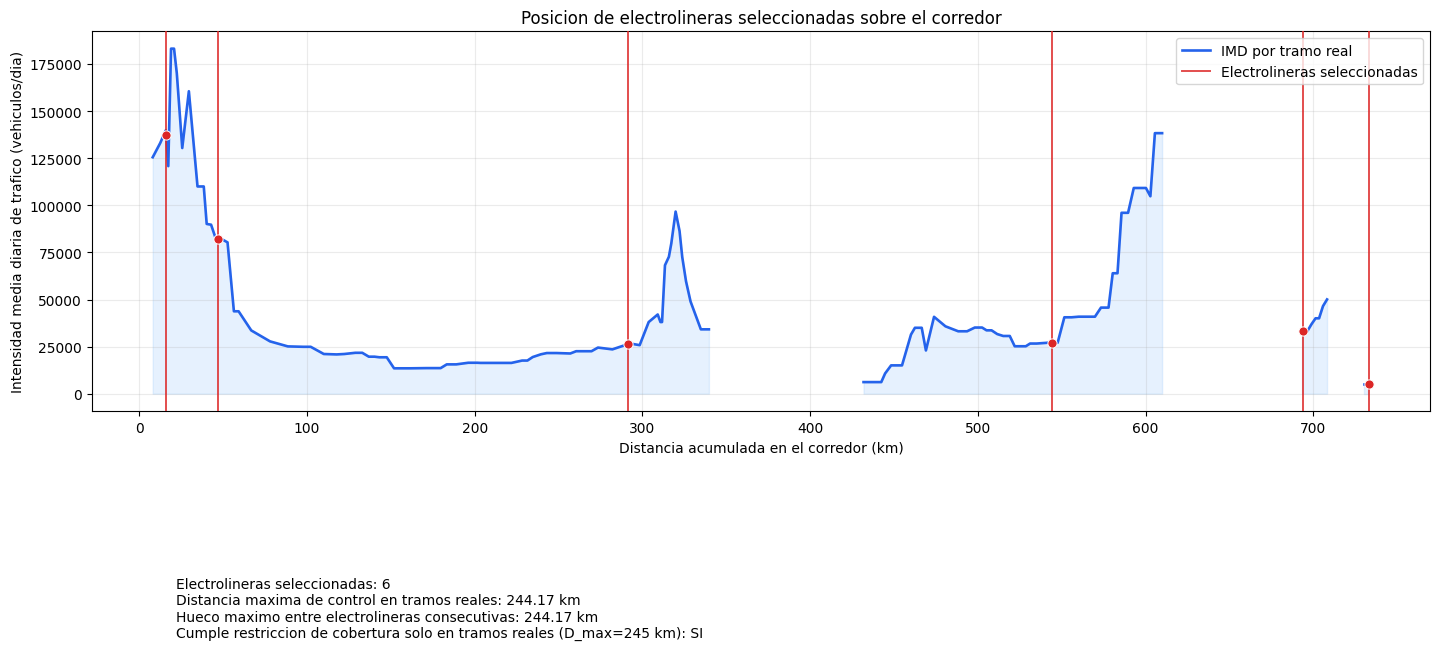

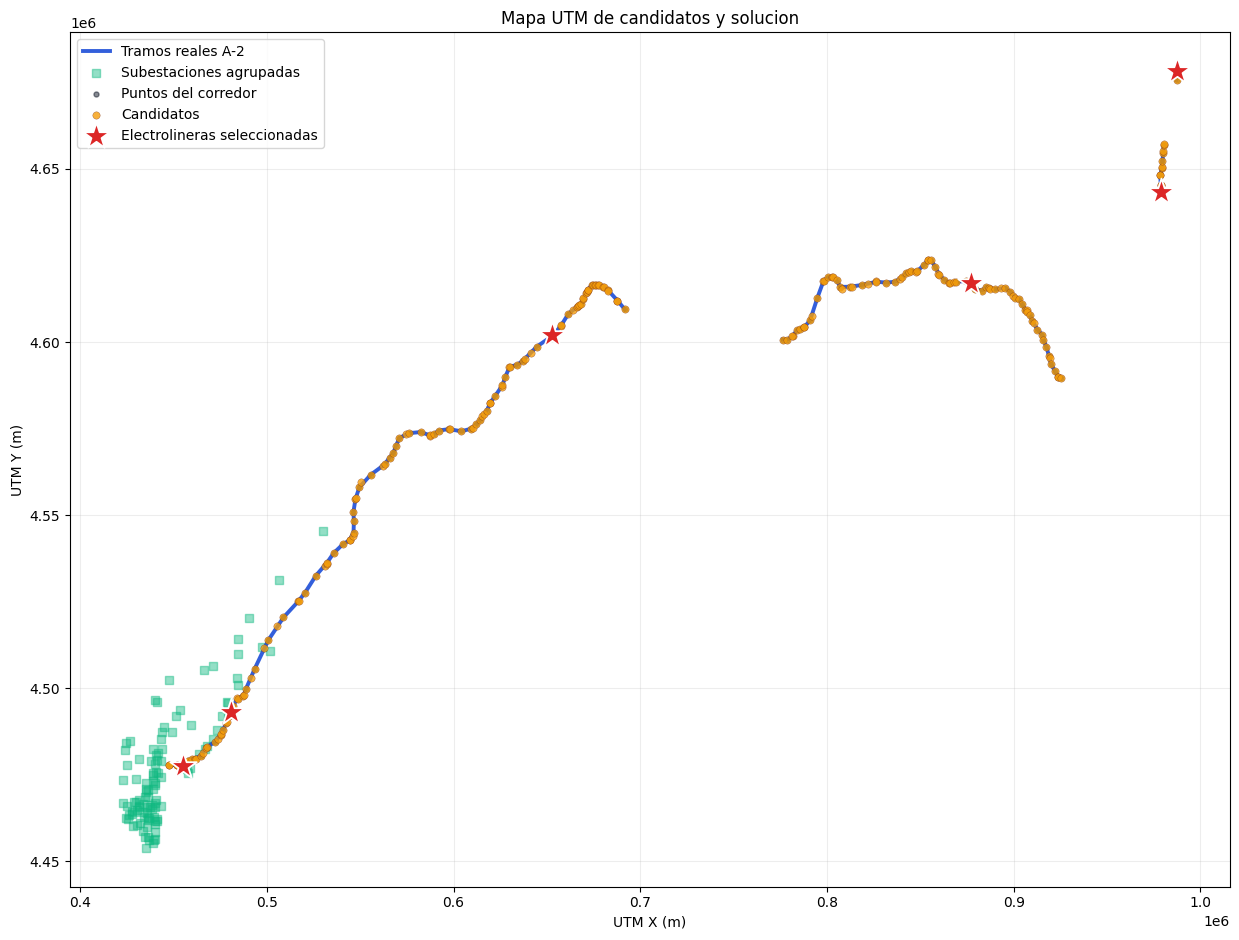

In [11]:

def add_station_cost_columns(sol):
    sol = sol.copy()
    sol['coste_cargadores'] = 35 * sol['p50'] + 80 * sol['p150'] + 150 * sol['p350']
    sol['coste_refuerzo'] = 500 * sol['refuerzo_mw']
    sol['coste_total_estimado'] = sol['coste_fijo'] + sol['coste_cargadores'] + sol['coste_refuerzo']
    return sol


def selected_station_table(sol, method_label):
    sol = add_station_cost_columns(sol)
    table = sol[['candidate_id', 'pk', 'capacidad_entorno_mw', 'puntos_total', 'coste_total_estimado']].copy()
    table['Metodo'] = method_label
    table = table.rename(columns={
        'candidate_id': 'Estacion seleccionada',
        'pk': 'PK / km',
        'capacidad_entorno_mw': 'Potencia disponible (MW)',
        'puntos_total': 'No. cargadores',
        'coste_total_estimado': 'Coste',
    })
    return table.sort_values('PK / km').reset_index(drop=True)


def coverage_metrics(sol):
    spacing = spacing_by_real_segment(sol)
    gaps = station_gaps_on_real_segments(sol)
    max_gap = float(gaps.max()) if len(gaps) else 0.0
    mean_gap = float(gaps.mean()) if len(gaps) else 0.0
    first_segment = spacing.sort_values('pk_inicio').iloc[0]
    last_segment = spacing.sort_values('pk_fin').iloc[-1]
    return {
        'numero_electrolineras': int(len(sol)),
        'distancia_inicio_corredor_a_primera_km': float(first_segment['distancia_inicio_a_primera_km']),
        'distancia_ultima_electrolinera_a_fin_corredor_km': float(last_segment['distancia_ultima_a_fin_km']),
        'distancia_inicio_a_primera_max_km': float(spacing['distancia_inicio_a_primera_km'].max(skipna=True)),
        'distancia_ultima_a_fin_max_km': float(spacing['distancia_ultima_a_fin_km'].max(skipna=True)),
        'hueco_maximo_entre_electrolineras_consecutivas_km': max_gap,
        'distancia_media_entre_electrolineras_km': mean_gap,
        'distancia_maxima_control_km': float(spacing['distancia_maxima_control_km'].max()),
        'distancia_maxima_permitida_km': PARAMS['distancia_max_km'],
        'cumple_restriccion_cobertura': coverage_ok_on_real_segments(sol),
        'estaciones_sin_potencia_minima': count_power_violations(sol),
        'pares_menores_separacion_minima': count_close_station_pairs(sol),
    }

def subestaciones_para_mapa(subestaciones):
    base = subestaciones.dropna(subset=['utm_x', 'utm_y']).copy()
    if base.empty:
        return base
    base['utm_x_round'] = base['utm_x'].round(1)
    base['utm_y_round'] = base['utm_y'].round(1)
    grouped = base.groupby(['utm_x_round', 'utm_y_round'], as_index=False).agg(
        utm_x=('utm_x', 'mean'),
        utm_y=('utm_y', 'mean'),
        puntos_conexion=('utm_x', 'size'),
        capacidad_disponible_mw=('capacidad_disponible_mw', 'max'),
    )
    return grouped


def imd_en_pk_real(pk):
    for segmento in segmentos_a2:
        seg = segmento.sort_values('pk_centro')
        pk_min = float(seg['pk_inicio'].min())
        pk_max = float(seg['pk_fin'].max())
        if pk_min <= pk <= pk_max:
            return float(np.interp(pk, seg['pk_centro'], seg['imd_total']))
    idx = (tramos['pk_centro'] - pk).abs().idxmin()
    return float(tramos.loc[idx, 'imd_total'])


subestaciones_mapa = subestaciones_para_mapa(subestaciones)
carretera_a2 = tramos.dropna(subset=['utm_x', 'utm_y']).sort_values('pk_centro').copy()
segmentos_a2 = tramos_reales_a2(tramos, max_hueco_pk=5.0)

resumen_estaciones = pd.concat([
    selected_station_table(sol_exacta, 'Exacto PuLP' if info_exacta['estado'] in ['Optimal', 'Feasible'] else 'Exacto respaldo'),
    selected_station_table(sol_heur, 'Heuristica voraz'),
], ignore_index=True)
metricas_corredor = coverage_metrics(sol_exacta)

display(pd.DataFrame([metricas_corredor]))
display(resumen_estaciones)

if HAS_MATPLOTLIB:
    fig, ax = plt.subplots(figsize=(14.5, 5.4))
    for idx, segmento in enumerate(segmentos_a2):
        seg = segmento.sort_values('pk_centro')
        ax.plot(seg['pk_centro'], seg['imd_total'], color='#2563EB', linewidth=1.9, label='IMD por tramo real' if idx == 0 else None, zorder=2)
        ax.fill_between(seg['pk_centro'], seg['imd_total'], color='#93C5FD', alpha=0.23, zorder=1)
    for idx, (_, row) in enumerate(sol_exacta.sort_values('pk').iterrows()):
        y_val = imd_en_pk_real(row['pk'])
        ax.axvline(row['pk'], color='#DC2626', alpha=0.82, linewidth=1.4, label='Electrolineras seleccionadas' if idx == 0 else None, zorder=3)
        ax.scatter(row['pk'], y_val, color='#DC2626', s=44, edgecolor='white', linewidth=0.7, zorder=4)
    ax.set_title('Posicion de electrolineras seleccionadas sobre el corredor')
    ax.set_xlabel('Distancia acumulada en el corredor (km)')
    ax.set_ylabel('Intensidad media diaria de trafico (vehiculos/dia)')
    ax.grid(alpha=0.25)
    ax.legend(loc='upper right')
    text = (
        f"Electrolineras seleccionadas: {metricas_corredor['numero_electrolineras']}\n"
        f"Distancia maxima de control en tramos reales: {metricas_corredor['distancia_maxima_control_km']:.2f} km\n"
        f"Hueco maximo entre electrolineras consecutivas: {metricas_corredor['hueco_maximo_entre_electrolineras_consecutivas_km']:.2f} km\n"
        f"Cumple restriccion de cobertura solo en tramos reales (D_max={PARAMS['distancia_max_km']:.0f} km): {'SI' if metricas_corredor['cumple_restriccion_cobertura'] else 'NO'}"
    )
    fig.text(0.125, -0.08, text, ha='left', va='top', fontsize=10)
    fig.tight_layout(rect=[0, 0.12, 1, 1])
    plt.show()

    fig, ax = plt.subplots(figsize=(12.5, 9.5))
    for idx, segmento in enumerate(segmentos_a2):
        seg = segmento.sort_values('pk_centro')
        ax.plot(seg['utm_x'], seg['utm_y'], color='#1D4ED8', linewidth=2.8, alpha=0.90, label='Tramos reales A-2' if idx == 0 else None, zorder=3)
    ax.scatter(subestaciones_mapa['utm_x'], subestaciones_mapa['utm_y'], s=34, color='#10B981', alpha=0.45, marker='s', label='Subestaciones agrupadas', zorder=2)
    ax.scatter(carretera_a2['utm_x'], carretera_a2['utm_y'], s=13, color='#111827', alpha=0.50, label='Puntos del corredor', zorder=4)
    ax.scatter(candidatos['utm_x'], candidatos['utm_y'], s=28, color='#F59E0B', edgecolor='#7C2D12', linewidth=0.25, alpha=0.80, label='Candidatos', zorder=7)
    ax.scatter(sol_exacta['utm_x'], sol_exacta['utm_y'], s=400, color='#DC2626', edgecolor='white', linewidth=1.3, marker='*', label='Electrolineras seleccionadas', zorder=10)
    ax.set_title('Mapa UTM de candidatos y solucion')
    ax.set_xlabel('UTM X (m)')
    ax.set_ylabel('UTM Y (m)')
    ax.grid(alpha=0.22)
    ax.legend(loc='best', frameon=True)
    fig.tight_layout()
    plt.show()


## Análisis de sensibilidad de la distancia máxima

Se prueban varios valores alternativos de `D_max` sin modificar el caso base del notebook. Para cada valor se ejecuta la heur?stica voraz y, si PuLP est? disponible, un ILP con l?mite de tiempo reducido.


In [ ]:

D_MAX_VALUES = [90, 120, 150, 180, 210, 245]
SENSIBILIDAD_ILP_TIME_LIMIT = 120


def set_distancia_maxima_temporal(dmax_km):
    PARAMS['distancia_max_km'] = float(dmax_km)
    PARAMS['radio_cobertura_km'] = float(dmax_km) / 2


def coste_total_solucion(sol):
    if sol is None or len(sol) == 0:
        return np.nan
    return float((
        sol['coste_fijo']
        + 35 * sol['p50']
        + 80 * sol['p150']
        + 150 * sol['p350']
        + 500 * sol['refuerzo_mw']
    ).sum())


def fila_sensibilidad(dmax, metodo, estado, sol, tiempo_s, coste=None):
    if sol is not None and len(sol) > 0:
        metricas = coverage_metrics(sol)
        coste_total = coste_total_solucion(sol) if coste is None else float(coste)
        return {
            'D_max_km': float(dmax),
            'metodo': metodo,
            'estado_solver': estado,
            'coste_total': coste_total,
            'num_estaciones': int(len(sol)),
            'cobertura_ok': bool(metricas['cumple_restriccion_cobertura']),
            'max_hueco_km': float(metricas['hueco_maximo_entre_electrolineras_consecutivas_km']),
            'tiempo_segundos': float(tiempo_s),
            'gap_vs_ilp_pct': np.nan,
            'estaciones_sin_potencia_minima': count_power_violations(sol),
            'pares_menores_separacion_minima': count_close_station_pairs(sol),
        }
    return {
        'D_max_km': float(dmax),
        'metodo': metodo,
        'estado_solver': estado,
        'coste_total': np.nan,
        'num_estaciones': np.nan,
        'cobertura_ok': False,
        'max_hueco_km': np.nan,
        'tiempo_segundos': float(tiempo_s),
        'gap_vs_ilp_pct': np.nan,
        'estaciones_sin_potencia_minima': np.nan,
        'pares_menores_separacion_minima': np.nan,
    }


def solve_ilp_pulp_sensibilidad(time_limit=SENSIBILIDAD_ILP_TIME_LIMIT):
    if not PULP_AVAILABLE:
        return None, None, {'estado': 'PuLP_no_disponible', 'tiempo_s': 0.0, 'objetivo': np.nan}

    start = time.perf_counter()
    try:
        cand_actual = repair_candidate_gaps(globals()['candidatos'])
        cover, checkpoints, checkpoint_cover = build_feasible_sets(tramos, cand_actual)
    except Exception as exc:
        return None, None, {'estado': f'Preproceso_no_factible: {exc}', 'tiempo_s': time.perf_counter() - start, 'objetivo': np.nan}

    model = pulp.LpProblem('sensibilidad_red_recarga_a2', pulp.LpMinimize)
    I = list(cand_actual.index)
    T = list(tramos.index)
    x = pulp.LpVariable.dicts('abrir', I, lowBound=0, upBound=1, cat='Binary')
    p50 = pulp.LpVariable.dicts('p50', I, lowBound=0, upBound=PARAMS['puntos_max'], cat='Integer')
    p150 = pulp.LpVariable.dicts('p150', I, lowBound=0, upBound=PARAMS['puntos_max'], cat='Integer')
    p350 = pulp.LpVariable.dicts('p350', I, lowBound=0, upBound=PARAMS['puntos_max'], cat='Integer')
    refuerzo = pulp.LpVariable.dicts('refuerzo_mw', I, lowBound=0, cat='Continuous')

    assign = {}
    for t in T:
        for i in cover[t]:
            assign[(t, i)] = pulp.LpVariable(f'sens_asig_{t}_{i}', lowBound=0, upBound=1, cat='Binary')

    cap50 = float(POWER.loc[POWER['tipo'] == '50kW', 'capacidad_dia_por_punto'].iloc[0])
    cap150 = float(POWER.loc[POWER['tipo'] == '150kW', 'capacidad_dia_por_punto'].iloc[0])
    cap350 = float(POWER.loc[POWER['tipo'] == '350kW', 'capacidad_dia_por_punto'].iloc[0])

    for i in I:
        puntos_i = p50[i] + p150[i] + p350[i]
        model += puntos_i >= PARAMS['puntos_min'] * x[i]
        model += puntos_i <= PARAMS['puntos_max'] * x[i]
        potencia_i = 0.050 * p50[i] + 0.150 * p150[i] + 0.350 * p350[i]
        capacidad_i = float(cand_actual.loc[i, 'capacidad_entorno_mw'])
        model += refuerzo[i] >= PARAMS['potencia_minima_mw'] * x[i] - capacidad_i
        model += potencia_i <= capacidad_i + refuerzo[i]

    add_min_separation_constraints_pulp(model, x, cand_actual, prefix='sens_separacion_minima')

    for t in T:
        model += pulp.lpSum(assign[(t, i)] for i in cover[t]) == 1
        for i in cover[t]:
            model += assign[(t, i)] <= x[i]

    for _, feasible in checkpoint_cover.items():
        model += pulp.lpSum(x[i] for i in feasible) >= 1

    for i in I:
        demanda_asignada = pulp.lpSum(
            float(tramos.loc[t, 'demanda_cargas_dia']) * assign[(t, i)]
            for t in T if (t, i) in assign
        )
        capacidad_servicio = cap50 * p50[i] + cap150 * p150[i] + cap350 * p350[i]
        model += demanda_asignada <= capacidad_servicio

    model += pulp.lpSum(
        float(cand_actual.loc[i, 'coste_fijo']) * x[i]
        + 35 * p50[i]
        + 80 * p150[i]
        + 150 * p350[i]
        + 500 * refuerzo[i]
        for i in I
    )

    solver = pulp.PULP_CBC_CMD(msg=False, timeLimit=time_limit)
    status_code = model.solve(solver)
    elapsed = time.perf_counter() - start
    status = pulp.LpStatus[status_code]
    objetivo = float(pulp.value(model.objective)) if pulp.value(model.objective) is not None else np.nan

    if status not in ['Optimal', 'Feasible']:
        return None, None, {'estado': status, 'tiempo_s': elapsed, 'objetivo': objetivo}

    opened = [i for i in I if pulp.value(x[i]) is not None and pulp.value(x[i]) > 0.5]
    if not opened:
        return None, None, {'estado': 'Sin_estaciones_abiertas', 'tiempo_s': elapsed, 'objetivo': objetivo}

    solution = cand_actual.loc[opened].copy()
    solution['abierta'] = 1
    solution['p50'] = [int(round(pulp.value(p50[i]))) for i in opened]
    solution['p150'] = [int(round(pulp.value(p150[i]))) for i in opened]
    solution['p350'] = [int(round(pulp.value(p350[i]))) for i in opened]
    solution['puntos_total'] = solution[['p50', 'p150', 'p350']].sum(axis=1)
    solution['potencia_total_mw'] = 0.050 * solution['p50'] + 0.150 * solution['p150'] + 0.350 * solution['p350']
    solution['refuerzo_mw'] = [float(pulp.value(refuerzo[i])) for i in opened]
    solution['metodo'] = 'ilp_pulp_sensibilidad'

    assignments = []
    for (t, i), var in assign.items():
        if pulp.value(var) is not None and pulp.value(var) > 0.5:
            assignments.append({
                'tramo_id': tramos.loc[t, 'tramo_id'],
                'candidate_id': cand_actual.loc[i, 'candidate_id'],
                'demanda_cargas_dia': tramos.loc[t, 'demanda_cargas_dia'],
                'distancia_km': abs(tramos.loc[t, 'pk_centro'] - cand_actual.loc[i, 'pk']),
                'metodo': 'ilp_pulp_sensibilidad',
            })
    return solution.sort_values('pk').reset_index(drop=True), pd.DataFrame(assignments), {'estado': status, 'tiempo_s': elapsed, 'objetivo': objetivo}


def ejecutar_sensibilidad_distancia_maxima():
    base_dmax = PARAMS['distancia_max_km']
    rows = []
    try:
        for dmax in D_MAX_VALUES:
            set_distancia_maxima_temporal(dmax)

            start_h = time.perf_counter()
            try:
                sol_h, asig_h, info_h = solve_greedy(tramos, candidatos)
                tiempo_h = time.perf_counter() - start_h
                rows.append(fila_sensibilidad(dmax, 'heuristica_voraz', info_h['estado'], sol_h, tiempo_h, info_h['objetivo']))
            except Exception as exc:
                rows.append(fila_sensibilidad(dmax, 'heuristica_voraz', f'Error: {exc}', None, time.perf_counter() - start_h))

            sol_i, asig_i, info_i = solve_ilp_pulp_sensibilidad(SENSIBILIDAD_ILP_TIME_LIMIT)
            rows.append(fila_sensibilidad(dmax, 'ilp_pulp', info_i['estado'], sol_i, info_i['tiempo_s'], info_i['objetivo']))
    finally:
        set_distancia_maxima_temporal(base_dmax)

    results = pd.DataFrame(rows)
    for dmax in D_MAX_VALUES:
        ilp_mask = (
            (results['D_max_km'] == float(dmax))
            & (results['metodo'] == 'ilp_pulp')
            & (results['estado_solver'].isin(['Optimal', 'Feasible']))
            & (results['coste_total'].notna())
        )
        if ilp_mask.any():
            ilp_cost = float(results.loc[ilp_mask, 'coste_total'].iloc[0])
            heur_mask = (results['D_max_km'] == float(dmax)) & (results['metodo'] == 'heuristica_voraz') & (results['coste_total'].notna())
            results.loc[ilp_mask, 'gap_vs_ilp_pct'] = 0.0
            results.loc[heur_mask, 'gap_vs_ilp_pct'] = (results.loc[heur_mask, 'coste_total'] - ilp_cost) / ilp_cost * 100
    return results


sensibilidad_distancia = ejecutar_sensibilidad_distancia_maxima()
OUTPUT_DIR.mkdir(exist_ok=True)
sensibilidad_distancia.to_csv(OUTPUT_DIR / 'sensibilidad_distancia_maxima.csv', index=False)
display(sensibilidad_distancia)


def _scale_sens(value, vmin, vmax, out_min, out_max):
    return (out_min + out_max) / 2 if vmax == vmin else out_min + (value - vmin) * (out_max - out_min) / (vmax - vmin)


def save_sensitivity_plot_pillow(df, y_col, title, y_label, output_path):
    if not HAS_PIL:
        print('No hay Matplotlib ni Pillow: se omite', output_path)
        return
    plot_df = df.dropna(subset=[y_col]).copy()
    if plot_df.empty:
        print('Sin datos para', output_path)
        return
    font = ImageFont.load_default()
    width, height = 980, 600
    margin_left, margin_right, margin_top, margin_bottom = 95, 45, 65, 95
    plot = [margin_left, margin_top, width - margin_right, height - margin_bottom]
    img = Image.new('RGB', (width, height), 'white')
    draw = ImageDraw.Draw(img)
    draw.text((margin_left, 24), title, fill=(20, 20, 20), font=font)
    draw.rectangle(plot, outline=(170, 170, 170))

    xmin, xmax = float(min(D_MAX_VALUES)), float(max(D_MAX_VALUES))
    ymin, ymax = float(plot_df[y_col].min()), float(plot_df[y_col].max())
    if ymax == ymin:
        ymax = ymin + 1
    y_padding = 0.08 * (ymax - ymin)
    ymin_plot, ymax_plot = ymin - y_padding, ymax + y_padding

    for x_tick in D_MAX_VALUES:
        x = _scale_sens(x_tick, xmin, xmax, plot[0], plot[2])
        draw.line([(x, plot[3]), (x, plot[3] + 5)], fill=(80, 80, 80), width=1)
        draw.text((x - 10, plot[3] + 10), str(x_tick), fill=(20, 20, 20), font=font)
        draw.line([(x, plot[1]), (x, plot[3])], fill=(235, 235, 235), width=1)

    for frac in np.linspace(0, 1, 5):
        y_value = ymin_plot + frac * (ymax_plot - ymin_plot)
        y = _scale_sens(y_value, ymin_plot, ymax_plot, plot[3], plot[1])
        draw.line([(plot[0] - 5, y), (plot[0], y)], fill=(80, 80, 80), width=1)
        label = f'{y_value:.0f}' if y_value >= 10 else f'{y_value:.1f}'
        draw.text((plot[0] - 78, y - 6), label, fill=(20, 20, 20), font=font)
        draw.line([(plot[0], y), (plot[2], y)], fill=(235, 235, 235), width=1)

    colors = {'heuristica_voraz': (220, 38, 38), 'ilp_pulp': (37, 99, 235)}
    labels = {'heuristica_voraz': 'Heuristica voraz', 'ilp_pulp': 'ILP PuLP'}
    for metodo, group in plot_df.groupby('metodo'):
        group = group.sort_values('D_max_km')
        points = [
            (_scale_sens(r['D_max_km'], xmin, xmax, plot[0], plot[2]), _scale_sens(r[y_col], ymin_plot, ymax_plot, plot[3], plot[1]))
            for _, r in group.iterrows()
        ]
        color = colors.get(metodo, (80, 80, 80))
        if len(points) > 1:
            draw.line(points, fill=color, width=3)
        for x, y in points:
            draw.ellipse([x - 5, y - 5, x + 5, y + 5], fill=color, outline=(255, 255, 255))

    draw.text((width // 2 - 45, height - 42), 'D_max (km)', fill=(20, 20, 20), font=font)
    draw.text((12, margin_top - 24), y_label, fill=(20, 20, 20), font=font)
    lx, ly = width - 230, 88
    for metodo, color in colors.items():
        if metodo in set(plot_df['metodo']):
            draw.line([(lx, ly + 6), (lx + 24, ly + 6)], fill=color, width=3)
            draw.ellipse([lx + 9, ly + 1, lx + 17, ly + 9], fill=color, outline=(255, 255, 255))
            draw.text((lx + 34, ly), labels[metodo], fill=(20, 20, 20), font=font)
            ly += 22
    img.save(output_path)

if HAS_MATPLOTLIB:
    for y_col, title, y_label, file_name in [
        ('coste_total', 'Sensibilidad: coste total frente a D_max', 'Coste total estimado', 'sensibilidad_coste_vs_dmax.png'),
        ('num_estaciones', 'Sensibilidad: numero de electrolineras frente a D_max', 'Numero de electrolineras', 'sensibilidad_estaciones_vs_dmax.png'),
    ]:
        fig, ax = plt.subplots(figsize=(8.8, 5.0))
        for metodo, group in sensibilidad_distancia.dropna(subset=[y_col]).groupby('metodo'):
            group = group.sort_values('D_max_km')
            ax.plot(group['D_max_km'], group[y_col], marker='o', linewidth=2, label=metodo)
        ax.set_title(title)
        ax.set_xlabel('D_max (km)')
        ax.set_ylabel(y_label)
        ax.grid(alpha=0.25)
        ax.legend()
        fig.tight_layout()
        fig.savefig(OUTPUT_DIR / file_name, dpi=170, bbox_inches='tight')
        plt.show()
else:
    save_sensitivity_plot_pillow(
        sensibilidad_distancia,
        'coste_total',
        'Sensibilidad: coste total frente a D_max',
        'Coste total estimado',
        OUTPUT_DIR / 'sensibilidad_coste_vs_dmax.png',
    )
    save_sensitivity_plot_pillow(
        sensibilidad_distancia,
        'num_estaciones',
        'Sensibilidad: numero de electrolineras frente a D_max',
        'Numero de electrolineras',
        OUTPUT_DIR / 'sensibilidad_estaciones_vs_dmax.png',
    )
    display(Image.open(OUTPUT_DIR / 'sensibilidad_coste_vs_dmax.png'))
    display(Image.open(OUTPUT_DIR / 'sensibilidad_estaciones_vs_dmax.png'))


### Interpretación del análisis de sensibilidad

Cuando aumenta `D_max`, cada electrolinera cubre un intervalo mayor del corredor. Por tanto, el n?mero necesario de estaciones tiende a bajar o mantenerse, y el coste total normalmente disminuye. Los valores peque?os de `D_max` obligan a colocar m?s estaciones para evitar huecos entre recargas; los valores grandes relajan la restricci?n de cobertura, aunque pueden concentrar m?s demanda en menos puntos.


## 11. Exportacion de resultados a `output/`

Esta celda crea unicamente la carpeta `output/` y guarda tablas CSV, graficos PNG y un resumen JSON/TXT de resultados.

In [13]:

def _scale(value, vmin, vmax, out_min, out_max):
    return (out_min + out_max) / 2 if vmax == vmin else out_min + (value - vmin) * (out_max - out_min) / (vmax - vmin)


def save_pillow_visuals(output_dir):
    if not HAS_PIL:
        print('No hay Matplotlib ni Pillow: se omiten PNG.')
        return
    font = ImageFont.load_default()

    width, height = 1400, 650
    m_left, m_right, m_top, m_bottom = 95, 45, 70, 185
    img = Image.new('RGB', (width, height), 'white')
    draw = ImageDraw.Draw(img)
    draw.text((m_left, 25), 'Posicion de electrolineras seleccionadas sobre el corredor', fill=(20, 20, 20), font=font)
    plot = [m_left, m_top, width - m_right, height - m_bottom]
    draw.rectangle(plot, outline=(190, 190, 190))
    xmin, xmax = tramos['pk_centro'].min(), tramos['pk_centro'].max()
    ymin, ymax = 0, tramos['imd_total'].max()
    for segmento in segmentos_a2:
        seg = segmento.sort_values('pk_centro')
        points = [
            (_scale(r['pk_centro'], xmin, xmax, plot[0], plot[2]), _scale(r['imd_total'], ymin, ymax, plot[3], plot[1]))
            for _, r in seg.iterrows()
        ]
        if len(points) > 1:
            draw.line(points, fill=(37, 99, 235), width=3)
    for _, r in sol_exacta.sort_values('pk').iterrows():
        x = _scale(r['pk'], xmin, xmax, plot[0], plot[2])
        y = _scale(imd_en_pk_real(r['pk']), ymin, ymax, plot[3], plot[1])
        draw.line([(x, plot[1]), (x, plot[3])], fill=(220, 38, 38), width=2)
        draw.ellipse([x - 5, y - 5, x + 5, y + 5], fill=(220, 38, 38), outline=(255, 255, 255))
    draw.text((width // 2 - 135, height - 55), 'Distancia acumulada en el corredor (km)', fill=(20, 20, 20), font=font)
    draw.text((12, m_top - 28), 'Intensidad media diaria de trafico (vehiculos/dia)', fill=(20, 20, 20), font=font)
    lines = [
        f"Electrolineras seleccionadas: {metricas_corredor['numero_electrolineras']}",
        f"Distancia maxima de control en tramos reales: {metricas_corredor['distancia_maxima_control_km']:.2f} km",
        f"Hueco maximo entre electrolineras consecutivas: {metricas_corredor['hueco_maximo_entre_electrolineras_consecutivas_km']:.2f} km",
        f"Cumple restriccion solo en tramos reales (D_max={PARAMS['distancia_max_km']:.0f} km): {'SI' if metricas_corredor['cumple_restriccion_cobertura'] else 'NO'}",
    ]
    for i, line in enumerate(lines):
        draw.text((m_left, height - 140 + i * 22), line, fill=(20, 20, 20), font=font)
    img.save(output_dir / 'posicion_electrolineras_corredor.png')
    img.save(output_dir / 'perfil_corredor_solucion_exacta.png')

    width, height = 1100, 900
    m_left, m_right, m_top, m_bottom = 95, 45, 65, 75
    img = Image.new('RGB', (width, height), 'white')
    draw = ImageDraw.Draw(img)
    draw.text((m_left, 25), 'Mapa UTM de candidatos y solucion', fill=(20, 20, 20), font=font)
    plot = [m_left, m_top, width - m_right, height - m_bottom]
    draw.rectangle(plot, outline=(190, 190, 190))
    all_x = pd.concat([carretera_a2['utm_x'], candidatos['utm_x'], subestaciones_mapa['utm_x'], sol_exacta['utm_x']]).dropna()
    all_y = pd.concat([carretera_a2['utm_y'], candidatos['utm_y'], subestaciones_mapa['utm_y'], sol_exacta['utm_y']]).dropna()
    xmin, xmax = all_x.min(), all_x.max()
    ymin, ymax = all_y.min(), all_y.max()
    for _, r in subestaciones_mapa.dropna(subset=['utm_x', 'utm_y']).iterrows():
        x = _scale(r['utm_x'], xmin, xmax, plot[0], plot[2]); y = _scale(r['utm_y'], ymin, ymax, plot[3], plot[1])
        draw.rectangle([x - 4, y - 4, x + 4, y + 4], fill=(16, 185, 129), outline=(0, 80, 60))
    road_points_all = []
    for segmento in segmentos_a2:
        seg = segmento.sort_values('pk_centro')
        road_points = []
        for _, r in seg.dropna(subset=['utm_x', 'utm_y']).iterrows():
            x = _scale(r['utm_x'], xmin, xmax, plot[0], plot[2]); y = _scale(r['utm_y'], ymin, ymax, plot[3], plot[1])
            road_points.append((x, y))
            road_points_all.append((x, y))
        if len(road_points) > 1:
            draw.line(road_points, fill=(29, 78, 216), width=4)
    for x, y in road_points_all:
        draw.ellipse([x - 2, y - 2, x + 2, y + 2], fill=(17, 24, 39))
    for _, r in candidatos.dropna(subset=['utm_x', 'utm_y']).iterrows():
        x = _scale(r['utm_x'], xmin, xmax, plot[0], plot[2]); y = _scale(r['utm_y'], ymin, ymax, plot[3], plot[1])
        draw.ellipse([x - 4, y - 4, x + 4, y + 4], fill=(245, 158, 11), outline=(124, 45, 18))
    for _, r in sol_exacta.dropna(subset=['utm_x', 'utm_y']).sort_values('pk').iterrows():
        x = _scale(r['utm_x'], xmin, xmax, plot[0], plot[2]); y = _scale(r['utm_y'], ymin, ymax, plot[3], plot[1])
        draw.ellipse([x - 9, y - 9, x + 9, y + 9], fill=(220, 38, 38), outline=(255, 255, 255), width=2)
    draw.text((width // 2 - 40, height - 35), 'UTM X (m)', fill=(20, 20, 20), font=font)
    draw.text((12, m_top - 28), 'UTM Y (m)', fill=(20, 20, 20), font=font)
    legend = [('Tramos reales A-2', (29, 78, 216)), ('Puntos del corredor', (17, 24, 39)), ('Candidatos', (245, 158, 11)), ('Subestaciones agrupadas', (16, 185, 129)), ('Electrolineras seleccionadas', (220, 38, 38))]
    lx, ly = width - 330, 90
    for label, color in legend:
        draw.ellipse([lx + 6, ly, lx + 18, ly + 12], fill=color)
        draw.text((lx + 34, ly - 1), label, fill=(20, 20, 20), font=font)
        ly += 22
    img.save(output_dir / 'mapa_utm_solucion_exacta.png')


OUTPUT_DIR.mkdir(exist_ok=True)
tramos.to_csv(OUTPUT_DIR / 'tramos_limpios_a2.csv', index=False)
candidatos.to_csv(OUTPUT_DIR / 'candidatos_modelo_a2.csv', index=False)
sol_exacta.to_csv(OUTPUT_DIR / 'solucion_exacta_pulp_a2.csv', index=False)
sol_heur.to_csv(OUTPUT_DIR / 'solucion_heuristica_a2.csv', index=False)
asig_exacta.to_csv(OUTPUT_DIR / 'asignacion_exacta_pulp_a2.csv', index=False)
asig_heur.to_csv(OUTPUT_DIR / 'asignacion_heuristica_a2.csv', index=False)
comparacion.to_csv(OUTPUT_DIR / 'comparacion_resultados_a2.csv', index=False)
resumen_estaciones.to_csv(OUTPUT_DIR / 'tabla_estaciones_seleccionadas_a2.csv', index=False)

if HAS_MATPLOTLIB:
    fig, ax = plt.subplots(figsize=(14.5, 5.4))
    for idx, segmento in enumerate(segmentos_a2):
        seg = segmento.sort_values('pk_centro')
        ax.plot(seg['pk_centro'], seg['imd_total'], color='#2563EB', linewidth=1.9, label='IMD por tramo real' if idx == 0 else None, zorder=2)
        ax.fill_between(seg['pk_centro'], seg['imd_total'], color='#93C5FD', alpha=0.23, zorder=1)
    for idx, (_, row) in enumerate(sol_exacta.sort_values('pk').iterrows()):
        ax.axvline(row['pk'], color='#DC2626', alpha=0.82, linewidth=1.4, label='Electrolineras seleccionadas' if idx == 0 else None, zorder=3)
        ax.scatter(row['pk'], imd_en_pk_real(row['pk']), color='#DC2626', s=44, edgecolor='white', linewidth=0.7, zorder=4)
    ax.set_title('Posicion de electrolineras seleccionadas sobre el corredor')
    ax.set_xlabel('Distancia acumulada en el corredor (km)')
    ax.set_ylabel('Intensidad media diaria de trafico (vehiculos/dia)')
    ax.grid(alpha=0.25)
    ax.legend(loc='upper right')
    text = (
        f"Electrolineras seleccionadas: {metricas_corredor['numero_electrolineras']}\n"
        f"Distancia maxima de control en tramos reales: {metricas_corredor['distancia_maxima_control_km']:.2f} km\n"
        f"Hueco maximo entre electrolineras consecutivas: {metricas_corredor['hueco_maximo_entre_electrolineras_consecutivas_km']:.2f} km\n"
        f"Cumple restriccion de cobertura solo en tramos reales (D_max={PARAMS['distancia_max_km']:.0f} km): {'SI' if metricas_corredor['cumple_restriccion_cobertura'] else 'NO'}"
    )
    fig.text(0.125, -0.08, text, ha='left', va='top', fontsize=10)
    fig.tight_layout(rect=[0, 0.12, 1, 1])
    fig.savefig(OUTPUT_DIR / 'posicion_electrolineras_corredor.png', dpi=170, bbox_inches='tight')
    fig.savefig(OUTPUT_DIR / 'perfil_corredor_solucion_exacta.png', dpi=170, bbox_inches='tight')
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(12.5, 9.5))
    for idx, segmento in enumerate(segmentos_a2):
        seg = segmento.sort_values('pk_centro')
        ax.plot(seg['utm_x'], seg['utm_y'], color='#1D4ED8', linewidth=2.8, alpha=0.90, label='Tramos reales A-2' if idx == 0 else None, zorder=3)
    ax.scatter(subestaciones_mapa['utm_x'], subestaciones_mapa['utm_y'], s=34, color='#10B981', alpha=0.45, marker='s', label='Subestaciones agrupadas', zorder=2)
    ax.scatter(carretera_a2['utm_x'], carretera_a2['utm_y'], s=13, color='#111827', alpha=0.50, label='Puntos del corredor', zorder=4)
    ax.scatter(candidatos['utm_x'], candidatos['utm_y'], s=28, color='#F59E0B', edgecolor='#7C2D12', linewidth=0.25, alpha=0.80, label='Candidatos', zorder=7)
    ax.scatter(sol_exacta['utm_x'], sol_exacta['utm_y'], s=400, color='#DC2626', edgecolor='white', linewidth=1.3, marker='*', label='Electrolineras seleccionadas', zorder=10)
    ax.set_title('Mapa UTM de candidatos y solucion')
    ax.set_xlabel('UTM X (m)')
    ax.set_ylabel('UTM Y (m)')
    ax.grid(alpha=0.22)
    ax.legend(frameon=True)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'mapa_utm_solucion_exacta.png', dpi=170, bbox_inches='tight')
    plt.close(fig)
else:
    save_pillow_visuals(OUTPUT_DIR)

summary = {
    'parametros': PARAMS,
    'info_exacta': info_exacta,
    'info_heuristica': info_heur,
    'metricas_corredor_exacto': metricas_corredor,
    'comparacion': comparacion.to_dict(orient='records'),
    'tabla_estaciones': 'output/tabla_estaciones_seleccionadas_a2.csv',
}
with open(OUTPUT_DIR / 'resumen_resultados_a2.txt', 'w', encoding='utf-8') as f:
    f.write(json.dumps(summary, indent=2, ensure_ascii=False))

print('Resultados guardados en', OUTPUT_DIR)
for path in sorted(OUTPUT_DIR.iterdir()):
    print('-', path)


Resultados guardados en ..\output
- ..\output\asignacion_exacta_pulp_a2.csv
- ..\output\asignacion_heuristica_a2.csv
- ..\output\candidatos_modelo_a2.csv
- ..\output\comparacion_resultados_a2.csv
- ..\output\mapa_utm_solucion_exacta.png
- ..\output\perfil_corredor_solucion_exacta.png
- ..\output\posicion_electrolineras_corredor.png
- ..\output\resumen_resultados_a2.txt
- ..\output\sensibilidad_coste_vs_dmax.png
- ..\output\sensibilidad_distancia_maxima.csv
- ..\output\sensibilidad_estaciones_vs_dmax.png
- ..\output\solucion_exacta_pulp_a2.csv
- ..\output\solucion_heuristica_a2.csv
- ..\output\tabla_estaciones_seleccionadas_a2.csv
- ..\output\tramos_limpios_a2.csv


## 12. Conclusiones tecnicas

- El corredor se ha modelado como un grafo de candidatos conectados por distancia maxima admisible.
- El modelo exacto con PuLP decide simultaneamente que estaciones abrir, como asignar demanda y cuantos puntos de 50, 150 y 350 kW instalar.
- La heuristica voraz sirve como referencia sencilla y permite comparar coste, cobertura y tiempo de ejecucion.
- La restriccion de 500 kVA se incorpora mediante capacidad disponible y una variable de refuerzo electrico, porque los datos de subestaciones pueden ser insuficientes en algunos tramos.
- Los CSV y PNG exportados a `output/`
- La capacidad electrica se toma del CSV real de CNMC de demanda en distribucion filtrado a 15 km de la A-2; si no hay capacidad suficiente, se penaliza con refuerzo electrico.
